In [138]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from COMPAS.compas_python_utils.detailed_evolution_plotter import plot_detailed_evolution as det_evo
import tempfile

import h5py as h5 
from astropy import units as u
from astropy import constants as c

import os
import scipy

pd.options.display.max_columns = None

In [139]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
# rcParams['font.family'] = 'serif'
# rcParams["mathtext.fontset"] = 'stix'
# rcParams["font.size"] = 18
fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "12",
    "xtick.labelsize": "10",
    "ytick.labelsize": "10",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images


In [140]:
from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))
color_list = [colorPalette['red'], colorPalette['blue'], colorPalette['green']]

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']


In [141]:
frac_limit = 1e-4

In [142]:
columns_to_keep = ['Time', 'Mass(1)', 'Mass(2)', 'Radius(1)', 'Radius(2)', 'SemiMajorAxis', 'Eccentricity', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Period(1)', 'Period(2)', 'Period_Orb', 'dmMT(1)', 'dmMT(2)', 'Omega(1)', 'Omega(2)', 'Omega_Orb', 'Record_Type']
columns_to_keep_sanity = ['Time', 'M1', 'M2', 'R1', 'R2', 
                          'M1_conv_env', 'M1_core', 'M2_conv_env', 'M2_core',
                          'R1_conv_env_extent', 'R1_core', 'R2_conv_env_extent', 'R2_core',
                          'SemiMajorAxis_Rsun', 'ecc', 'StellarType_1', 'StellarType_2', 'Period1', 'Period2', 'Period_orb', 'J1_after', 'J2_after', 'Jorb_after', 'dM1_MT', 'dM2_MT', 
                          'ImK22_1', 'ImK22_2', 'ImK22_1_dyn', 'ImK22_2_dyn', 'ImK22_1_eq', 'ImK22_2_eq', 
                          'ImK22_Zahn_Equilibrium1', 'ImK22_Zahn_Equilibrium2', 'ImK22_Zahn_Dynamical1', 'ImK22_Zahn_Dynamical2']


1. INITIAL_STATE
    Record describes the initial state of the binary

2. POST_STELLAR_TIMESTEP
    Record was logged immediately following stellar timestep (i.e. the evolution of the constituent stars for a single timestep)

3.  POST_BINARY_TIMESTEP
    Record was logged immediately following binary timestep (i.e. the evolution of the binary system for a single timestep)

4.  TIMESTEP_COMPLETED
    Record was logged immediately following the completion of the timestep (after all changes to the binary and components)

5.  FINAL_STATE
    Record describes the final state of the binary

6.  STELLAR_TYPE_CHANGE_DURING_CEE
    Record was logged immediately following a stellar type change during a common envelope event

7.  STELLAR_TYPE_CHANGE_DURING_MT
    Record was logged immediately following a stellar type change during a mass transfer event

8.  STELLAR_TYPE_CHANGE_DURING_MASS_RESOLUTION
    Record was logged immediately following a stellar type change during mass resolution

9.  STELLAR_TYPE_CHANGE_DURING_CHE_EQUILIBRATION
    Record was logged immediately following a stellar type change during mass equilibration for CHE

10.  POST_MT
    Record was logged immediately following a mass transfer event

11.  POST_WINDS
    Record was logged immediately following winds mass loss

12.  POST_CEE
    Record was logged immediately following a common envelope event

13.  POST_SN
    Record was logged immediately following a supernova event

14.  POST_MASS_RESOLUTION
    Record was logged immediately following mass resolution (i.e. after winds mass loss & mass transfer complete)

15.  POST_MASS_RESOLUTION_MERGER
    Record was logged immediately following a merger after mass resolution

16.  PRE_STELLAR_TIMESTEP
    Record was logged immediately prior to stellar timestep (i.e. the evolution of the constituent stars for a single timestep)


# SMT BBH that stays narrow / spinning with Tides

In [130]:
notides_DataPath = 'sim_data/smt_notides'
tides_DataPath = 'sim_data/smt_realistic'
perfect_DataPath = 'sim_data/smt_perfect'
# perfect_DataPath = 'sim_data/smt_z77'

# # --------------

df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



# df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
# df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

# df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
# df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

# df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
# df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000056   Zero-age main-sequence, metallicity Z=0.0005   36.612     1     23.635     1     70.176  0.351
  5.651091   Star 1: MS->HG                    35.455     2     23.476     1     71.475  0.349
  5.652166   Stable mass transfer from 1 to 2   11.939     7     46.992     1     78.546  0.000
  5.652166   Star 1: HG->HeMS                  11.939     7     46.992     1     78.546  0.000
  6.227524   Star 1: HeMS->HeHG                11.876     8     46.800     1     80.808  0.000
  6.247324   Star 1 undergoes supernova and forms a BH   11.872    14     46.792     1     80.906  0.000
  8.807348   Star 2: MS->HG                    11.872    14     45.174     2     88.416  0.000
  8.809360   Stable mass transfer from 2 to 1   11.873    14     16.650     7     10.662  0.000
  8.809360   Star 2: HG->HeMS                  11.873    14     16.650     7     10.662  0.000
  9.281002   Star 2: HeMS->

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1738ad910>])

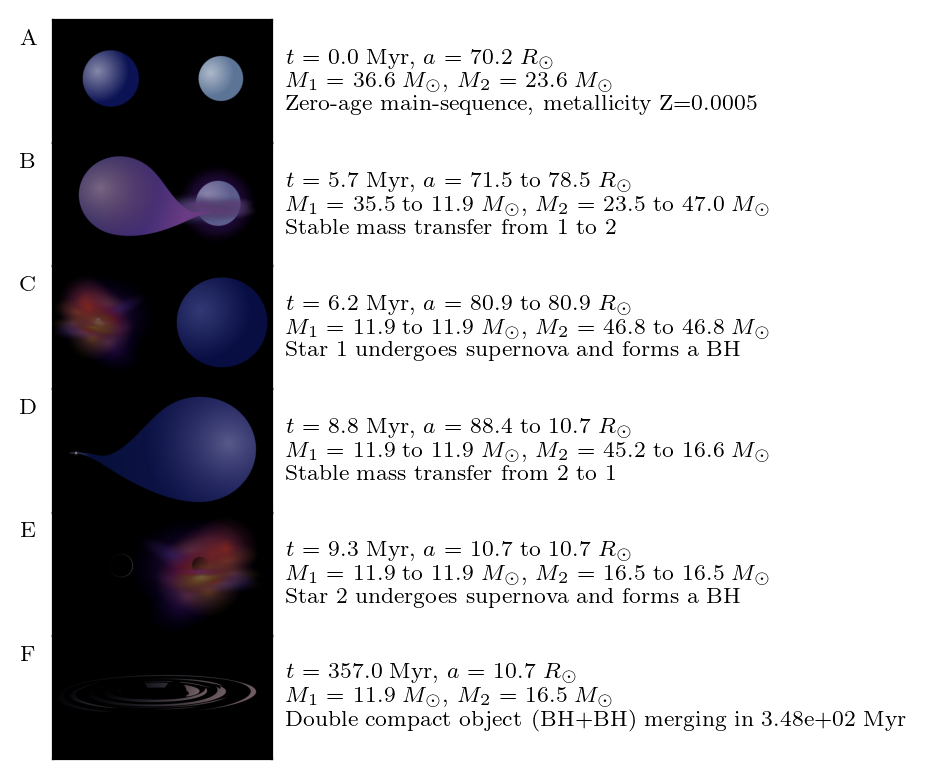

In [131]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [132]:
df_detailed_tides['Period(1)'] = (2 * np.pi / (df_detailed_tides['Omega(1)'].values / u.s)).to(u.day)
df_detailed_tides['Period(2)'] = (2 * np.pi / (df_detailed_tides['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_tides['Mass(1)'].values * u.M_sun + df_detailed_tides['Mass(2)'].values * u.M_sun) / (df_detailed_tides['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_tides['Omega_Orb'] = omega_orb.value
df_detailed_tides['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_tides_short = df_detailed_tides[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [133]:
# st_change_idx = np.where((df_detailed_tides['Stellar_Type(1)'] != df_detailed_tides['Stellar_Type(1)'].shift()) | (df_detailed_tides['Stellar_Type(2)'] != df_detailed_tides['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_tides_short.iloc[st_changes_with_buffer] # the +1 is to get the row after the change, which is after tidal effects

In [134]:
# df_dco_tides

In [135]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())
df_sanity_tides.head()

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1135,0.000000,0.000056,1,1,374.729,374.729,374.729,374.729,0.000000,0.000037,0.000000,0.000007,261.586,261.586,0.000000,0.012636,0.000000,0.006351,0.350775,0.350774,36.6118,6.10301,0.002949,0.002949,23.6347,4.73158,0.001144,0.001144,0.326353,0.326353,4.833800e-08,1.402600e-08,4.833800e-08,1.402600e-08,3.069270e-07,8.905960e-08,9.049240e-07,2.625780e-07,4.833800e-08,1.402600e-08,4.833800e-08,1.402600e-08,3.069270e-07,8.905960e-08,9.049240e-07,2.625780e-07,0,0,0,0,0,0,0,0,20.7124,3.20676,11.4761,2.22310,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,175845.0,62806.3,8.28917,7.27776,-1.784130e-09,-3.479590e-10,0.000254,0.000127,-2.395400e-09,-4.671740e-10,1.82920,1.46437,0.010313,0.010313,-0.000005,-8.969480e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.880360e-09,9.118570e-10,4.880360e-09,9.118570e-10,3.098840e-08,5.789930e-09,9.136410e-08,1.707070e-08,-1.801320e-10,-2.262140e-11,-2.418480e-10,-3.037180e-11,0.000026,0.000008
1,1135,0.000056,0.014071,1,1,374.722,374.722,374.722,374.714,0.000037,0.006898,0.000007,0.001345,261.574,261.600,0.012634,2.339030,0.006351,1.175770,0.350774,0.350745,36.6106,6.10292,0.002949,0.002949,23.6344,4.73157,0.001144,0.001144,0.326361,0.326339,4.832420e-08,1.402320e-08,4.831170e-08,1.402140e-08,3.068000e-07,8.903580e-08,9.045880e-07,2.625130e-07,4.832420e-08,1.402320e-08,4.831170e-08,1.402140e-08,3.068000e-07,8.903580e-08,9.045880e-07,2.625130e-07,0,0,0,0,0,0,0,0,20.7114,3.20665,11.4759,2.22307,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,175834.0,62805.1,8.28909,7.27773,-1.783130e-09,-3.478110e-10,0.000254,0.000127,-2.394010e-09,-4.669660e-10,1.83027,1.46522,0.010318,0.010318,-0.001189,-2.253050e-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.879240e-09,9.117210e-10,4.877990e-09,9.116030e-10,3.097730e-08,5.788690e-09,9.133520e-08,1.706740e-08,-1.800410e-10,-2.261300e-11,-2.417210e-10,-3.035990e-11,0.000026,0.000008
2,1135,0.014127,0.014064,1,1,374.715,374.715,374.707,374.699,0.006896,0.013769,0.001345,0.002704,261.588,261.614,2.334010,4.659960,1.174110,2.359810,0.350745,0.350715,36.6094,6.10891,0.002955,0.002955,23.6342,4.73478,0.001146,0.001146,0.326346,0.326324,4.743010e-08,1.384730e-08,4.520650e-08,1.351830e-08,2.940500e-07,8.687640e-08,8.739120e-07,2.571690e-07,4.743010e-08,1.384730e-08,4.520650e-08,1.351830e-08,2.940500e-07,8.687640e-08,8.739120e-07,2.571690e-07,0,0,0,0,0,0,0,0,20.6897,3.20120,11.4679,2.22053,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,176058.0,62860.5,8.28766,7.27687,-1.730620e-09,-3.418400e-10,0.000246,0.000125,-2.325550e-09,-4.591760e-10,1.88572,1.50822,0.010655,0.010655,-0.001192,-2.256240e-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.898900e-09,9.143190e-10,4.669230e-09,8.925960e-10,3

In [136]:
df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)


df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

df_sanity_tides.iloc[np.where(df_sanity_tides['StellarType_2'] == 7)]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
3858,1135,8.80936,8.587440e-07,14,7,51.8001,51.8001,51.7861,51.7861,0.000439,0.000439,0.013544,0.013544,3039.30,3039.30,1.687250e+09,1.687250e+09,229.574,229.574,0.0,0.0,11.8729,0.00005,2.602860e-13,2.602860e-13,16.6497,1.28002,0.000059,0.000059,0.049583,0.049583,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0,0,0,0,0,0,0,0,11.8729,0.00005,16.6497,1.280020,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,1.000000e-10,356068.0,0.445697,21.5911,-0.0,-0.000000e+00,0.0,0.000000e+00,-0.0,-0.0,inf,inf,inf,inf,0.0,0.000000e+00,0.000392,-28.5231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.867660e-27,-1.995110e-09,-3.790460e-11,1.289110e-09,-3.790450e-11,1.027440e-08,-3.790440e-11,3.254260e-08,5.638850e-35,-8.261070e-11,0.0,-0.0,-1.131330e-19,0.000731,10.661961,0.000001,9.996487,0.755086
3859,1135,8.80936,3.585560e-03,14,7,51.7992,51.7992,51.7852,51.7852,0.000439,0.000439,0.013541,0.013541,3039.15,3039.15,1.687250e+09,1.687250e+09,229.532,229.532,0.0,0.0,11.8729,0.00005,2.602860e-13,2.602860e-13,16.6490,1.27999,0.000059,0.000059,0.049584,0.049584,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0,0,0,0,0,0,0,0,11.8729,0.00005,16.6490,1.279990,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,1.000000e-10,356043.0,0.445697,21.5910,-0.0,-0.000000e+00,0.0,0.000000e+00,-0.0,-0.0,inf,inf,inf,inf,0.0,-6.858660e-04,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.867290e-27,-1.994530e-09,-3.790460e-11,1.288820e-09,-3.790450e-11,1.027170e-08,-3.790440e-11,3.253370e-08,5.637800e-35,-8.257030e-11,0.0,-0.0,-1.131070e-19,0.000731,10.662219,0.000001,9.998316,0.755123
3860,1135,8.81295,3.585540e-03,14,7,51.7983,51.7983,51.7843,51.7825,0.000439,0.000439,0.013537,0.015333,3039.01,3039.32,1.687250e+09,1.687260e+09,229.031,259.422,0.0,0.0,11.8729,0.00005,2.602860e-13,2.602860e-13,16.6483,1.28124,0.000059,0.000059,0.049585,0.049582,0.0,2.674470e-05,0.0,1.729940e-05,0.0,1.377970e-04,0.0,4.363770e-04,0.0,2.674470e-05,0.0,1.729940e-05,0.0,1.377970e-04,0.0,4.363770e-04,0,0,0,0,0,0,0,0,11.8729,0.00005,16.5794,1.271480,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,1.000000e-10,357238.0,0.445697,21.5985,-0.0,-1.113000e-06,0.0,9.832980e+00,-0.0,-0.0,4.455140e-04,inf,3.090630e-06,3.090630e-06,0.0,-6.889940e-04,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.866920e-27,-2.001940e-09,-3.790460e-11,1.294920e-09,-3.790450e-11,1.031460e-08,-3.790440e-11,3.266430e-08,5.636750e-35,-8.331160e-11,0.0,-0.0,-1.130820e-19,0.000736,10.661724,0.000001,8.846333,0.755081
3861,1135,8.81653

In [137]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,36.6118,23.6347,6.10301,4.73158,0.000000e+00,20.71240,0.000000e+00,11.47610,0.000000e+00,3.206760,0.000000e+00,2.223100,70.176389,3.507740e-01,1,1,181622.975652,3.613465e+05,8.773151,0.000037,0.000007,374.7290,0.000000,0.0000,3.069270e-07,8.905960e-08,3.069270e-07,8.905960e-08,0,0,0.0,0.000000e+00,3.098840e-08,5.789930e-09
1379,5.65109,35.4554,23.4764,15.22220,7.15803,0.000000e+00,11.90050,0.000000e+00,8.26563,0.000000e+00,1.042430,0.000000e+00,1.205570,71.475183,3.489320e-01,1,1,132.877855,5.164175e+01,9.117842,0.306864,0.115606,368.0890,0.000000,0.0000,2.014320e-13,3.795440e-11,2.014320e-13,3.795440e-11,0,0,0.0,0.000000e+00,8.530470e-07,1.613670e-08
1380,5.65109,35.4552,23.4764,14.88250,7.15803,2.492500e-260,11.90050,0.000000e+00,8.26562,4.917450e-130,1.042430,0.000000e+00,1.205570,71.475398,3.489320e-01,2,1,84.825057,5.164186e+01,9.117914,0.306848,0.115606,368.0880,0.000000,0.0000,2.012570e-13,3.795350e-11,2.012570e-13,3.795350e-11,0,0,inf,0.000000e+00,6.956400e-07,1.613640e-08
1563,5.65216,35.4549,23.4764,19.31470,7.15903,2.560210e-226,11.93940,0.000000e+00,8.26502,6.579140e-113,1.044520,0.000000e+00,1.205380,71.475828,3.489320e-01,2,1,142.353234,5.165663e+01,9.118023,0.306816,0.115605,368.0870,0.000000,0.0000,6.289790e-14,3.788080e-11,6.289790e-14,3.788080e-11,0,0,inf,0.000000e+00,2.240020e-06,1.614730e-08
1564,5.65216,11.9395,46.9918,1.04452,8.18978,0.000000e+00,11.93950,0.000000e+00,25.05290,0.000000e+00,1.044520,0.000000e+00,3.027620,78.546301,0.000000e+00,7,1,142.478732,3.960346e-01,10.503945,0.000454,39.499900,277.5390,-23.515400,23.5154,0.000000e+00,-1.139790e-04,0.000000e+00,-1.139790e-04,0,0,0.0,0.000000e+00,2.479020e-12,-5.113550e-04
1752,6.22752,11.8757,46.7997,1.04110,8.85768,0.000000e+00,8.34851,0.000000e+00,23.51670,0.000000e+00,0.000071,0.000000e+00,2.703920,80.808224,0.000000e+00,7,1,145.858233,5.040940e-01,10.984747,0.000438,36.152100,279.4670,0.000000,0.0000,0.000000e+00,-1.555830e-05,0.000000e+00,-1.555830e-05,0,0,0.0,0.000000e+00,2.144120e-12,-3.572120e-04
1753,6.22752,11.8755,46.7989,1.04110,8.85760,0.000000e+00,8.34851,0.000000e+00,23.51620,0.000000e+00,0.000071,0.000000e+00,2.703890,80.817900,0.000000e+00,8,1,43.339964,5.042779e-01,10.986851,0.000438,36.137800,279.4760,0.000000,0.0000,0.000000e+00,-1.555470e-05,0.000000e+00,-1.555470e-05,0,0,0.0,0.000000e+00,1.211370e-12,-3.571250e-04
1828,6.24693,11.8725,46.7924,1.12914,8.88425,0.000000e+00,8.82660,0.000000e+00,23.46460,0.000000e+00,0.000071,0.000000e+00,2.693010,80.904558,0.000000e+00,8,1,44.297748,5.090339e-01,11.005397,0.000435,36.010900,279.5390,0.000000,0.0000,0.000000e+00,-1.442900e-05,0.000000e+00,-1.442900e-05,0,0,0.0,0.000000e+00,1.697690e-12,-3.518270e-04
1829,6.24713,11.8725,46.7923,0.00005,8.88452,0.000000e+00,11.87250,0.000000e+00,23.46410,0.000000e+00,0.000050,0.000000e+00,2.692900,80.905419,0.000000e+00,14,1,0.000001,5.090836e-01,11.005608,0.000435,36.009500,279.5400,0.000000,0.0000,0.000000e+00,-1.441810e-05,0.000000e+00,-1.441810e-05,0,0,0.0,0.000000e+00,-3.697060e-11,-3.517740e-04
3036,8.80735,11.8725,45.1744,0.00005,17.94910,0.000000e+00,11.87250,0.000000e+00,16.50520,0.000000e+00,0.000050,0.000000e+00,1.273240,88.416277,0.000000e+00,14,1,0.000001,2.635707e+00,12.750197,0.000435,27.405900,286.0960,0.000000,0.0000,0.000000e+00,-6.167500e-12,0.000000e+00,-6.167500e-12,0,0,0.0,0.000000e+00,-3.697060e-11,-4.238430e-05


#### Breakdown by tidal mechanism

In [120]:
# Load full data for tidal breakdown
rc = df_sanity_tides["R1_core"].values * u.R_sun              # Rsol
R = df_sanity_tides["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity_tides["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint = R - Renv

rc2 = df_sanity_tides["R2_core"].values * u.R_sun              # Rsol
R2 = df_sanity_tides["R2"].values * u.R_sun                    # Rsol
Renv2 = df_sanity_tides["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2 = R2 - Renv2

L = df_sanity_tides["Lum_1"].values * u.L_sun                 # Lsol
L2 = df_sanity_tides["Lum_2"].values * u.L_sun                 # Lsol

M = df_sanity_tides["M1"].values * u.M_sun                    # Msol
Mc = df_sanity_tides["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity_tides["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity_tides["M2"].values * u.M_sun                   # Msol
Mc2 = df_sanity_tides["M2_core"].values * u.M_sun              # Msol
Menv2 = df_sanity_tides["M2_conv_env"].values * u.M_sun        # Msol


I1 = df_sanity_tides["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity_tides["tau_conv1"].values * u.yr                # yr
tau_conv2 = df_sanity_tides["tau_conv2"].values * u.yr                # yr


omega_orb = df_sanity_tides["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity_tides["Omega1_before"].values / u.yr   # 1/yr
omega_spin2 = df_sanity_tides["Omega2_before"].values / u.yr   # 1/yr

sma = df_sanity_tides["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity_tides["ecc_before"].values                           # 1
period_orb = 2 * np.pi / df_sanity_tides["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk10 = df_sanity_tides["ImK10_1"].values
Imk12 = df_sanity_tides["ImK12_1"].values
Imk22 = df_sanity_tides["ImK22_1"].values
Imk32 = df_sanity_tides["ImK32_1"].values

Imk10_dyn = df_sanity_tides["ImK10_1_dyn"].values
Imk12_dyn = df_sanity_tides["ImK12_1_dyn"].values
Imk22_dyn = df_sanity_tides["ImK22_1_dyn"].values
Imk32_dyn = df_sanity_tides["ImK32_1_dyn"].values

Imk10_eq = df_sanity_tides["ImK10_1_eq"].values
Imk12_eq = df_sanity_tides["ImK12_1_eq"].values
Imk22_eq = df_sanity_tides["ImK22_1_eq"].values
Imk32_eq = df_sanity_tides["ImK32_1_eq"].values

Imk10_2 = df_sanity_tides["ImK10_2"].values
Imk12_2 = df_sanity_tides["ImK12_2"].values
Imk22_2 = df_sanity_tides["ImK22_2"].values
Imk32_2 = df_sanity_tides["ImK32_2"].values

Imk10_2_dyn = df_sanity_tides["ImK10_2_dyn"].values
Imk12_2_dyn = df_sanity_tides["ImK12_2_dyn"].values
Imk22_2_dyn = df_sanity_tides["ImK22_2_dyn"].values
Imk32_2_dyn = df_sanity_tides["ImK32_2_dyn"].values

Imk10_2_eq = df_sanity_tides["ImK10_2_eq"].values
Imk12_2_eq = df_sanity_tides["ImK12_2_eq"].values
Imk22_2_eq = df_sanity_tides["ImK22_2_eq"].values
Imk32_2_eq = df_sanity_tides["ImK32_2_eq"].values

dadt = df_sanity_tides["dadt1"].values * u.AU / u.yr
dOmegadt = df_sanity_tides["dOmegadt1"].values / u.yr**2
dedt1 = df_sanity_tides["dedt1"].values / u.yr


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity_tides["Time"].values * 1e6 * u.yr          # yr
st1 = df_sanity_tides["StellarType_1"].values
st2 = df_sanity_tides["StellarType_2"].values

rc_AU = df_sanity_tides["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity_tides["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity_tides["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     


rc_AU2 = df_sanity_tides["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2 = df_sanity_tides["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2 = df_sanity_tides["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2 = R_AU2 - Renv_AU2                 
Mint2 = M2 - Mc2 - Menv2    

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

In [121]:
print("Equilibrium tides from turbulent viscosity:")
Imk22_eq[st_changes_with_buffer][1:]

Equilibrium tides from turbulent viscosity:


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [122]:
print("IGW dissipation from convective core -- radiative envelope boundary:")
E2_kushnir = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.)
l=2
m=2
imk22_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk22_core_gw[(rc_AU/R_AU < frac_limit) | (Mc/M < frac_limit) | (Menv/M > frac_limit) | (Renv/R_AU > frac_limit)] = 0.0
imk22_core_gw[np.isnan(imk22_core_gw)] = 0.0
imk22_core_gw[st_changes_with_buffer][1:]


IGW dissipation from convective core -- radiative envelope boundary:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [4.70876591e-07, 3.62451199e-11, 5.50725290e-11, 1.06268809e-11,
           7.75363294e-07, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]>

In [123]:
print("IGW dissipation from radiative zone -- convective shell boundary:")

dNlnr_cbrt = (G_AU_Msol_yr * Mint / (Rint_AU**2 * (R_AU - Rint_AU)))**(1/3)

alpha = Rint_AU/R_AU
beta = Mint/M

# one_minus_beta = 1-beta
one_minus_beta = Menv/M

# gamma = alpha**3 * (1-beta) / (beta * (1 - alpha**3))
rho_conv = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3))
rho_rad = Mint / (4 * np.pi * (Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

Epsilon = alpha**11 * (one_minus_beta) * (1-gamma)**2 * (2*alpha/3 - 1)**2 / (beta**2 * (1-alpha**3) * (1-alpha)**2)


l=2
m=2
imk22_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (2*(2+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk22_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk22_env_gw)
imk22_env_gw[(Renv_AU/R_AU < frac_limit) | (Menv/M < frac_limit)] = 0.0
imk22_env_gw[np.isnan(imk22_env_gw)] = 0.0

imk22_env_gw[st_changes_with_buffer][1:]

IGW dissipation from radiative zone -- convective shell boundary:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]>

In [124]:
print("Dynamical tides from inertial wave dissipation:")
alpha = Rint_AU/R_AU
beta = Mint/M
one_minus_beta = Menv/M

rho_conv = Menv / ((R_AU**3 - Rint_AU**3))
rho_rad = Mint / ((Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

eps = omega_spin / np.sqrt(G_AU_Msol_yr * M / R_AU**3)

b1 = (1 + 2*alpha + 3*alpha**2 + (3/2)*alpha**3)
b2 = 1 + ((1-gamma) / gamma) * alpha**3
b3 = 1 + (3*gamma/2) + ((5*alpha**3)/(2*gamma))*(1 + gamma/2 - (3*gamma**2)/2) - (9/4)*(1-gamma)*alpha**5
imk22_inertial = (100 * np.pi / 63) * eps**2 * (alpha**5 / (1 - alpha**5)) * (1-gamma)**2 * (1-alpha)**4 * b1**2 * b2 * b3**(-2)

imk22_inertial[((Renv_AU/R_AU < frac_limit) & (Menv/M < frac_limit)) | (omega_orb > 2*omega_spin) | (Mint/M < frac_limit)] = 0.0
imk22_inertial = np.sign(omega_orb - omega_spin) * np.abs(imk22_inertial)
imk22_inertial[np.isnan(imk22_inertial)] = 0.0

imk22_inertial[st_changes_with_buffer][1:]

Dynamical tides from inertial wave dissipation:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in subtract
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0., -0., -0., -0., -0.,
           -0., -0.]>

### No Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000042   Zero-age main-sequence, metallicity Z=0.0010   60.217     1     39.289     1     97.165  0.659
  3.183518   Stable mass transfer from 1 to 2   41.823     1     54.095     1     26.987  0.000
  5.092414   Star 1: MS->HG                    19.539     2     76.123     1     48.630  0.000
  5.098476   Stable mass transfer from 1 to 2   17.199     7     78.441     1     57.029  0.000
  5.098476   Star 1: HG->HeMS                  17.199     7     78.441     1     57.029  0.000
  5.561985   Star 1: HeMS->HeHG                17.006     8     76.496     1     63.310  0.000
  5.565597   Star 1 undergoes supernova and forms a BH   17.004    14     76.479     1     63.365  0.000
  6.079049   Stellar Merger: BH+MS             17.004    14     73.938     1     71.098  0.000


(<Figure size 900x480 with 5 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1734f7ed0>])

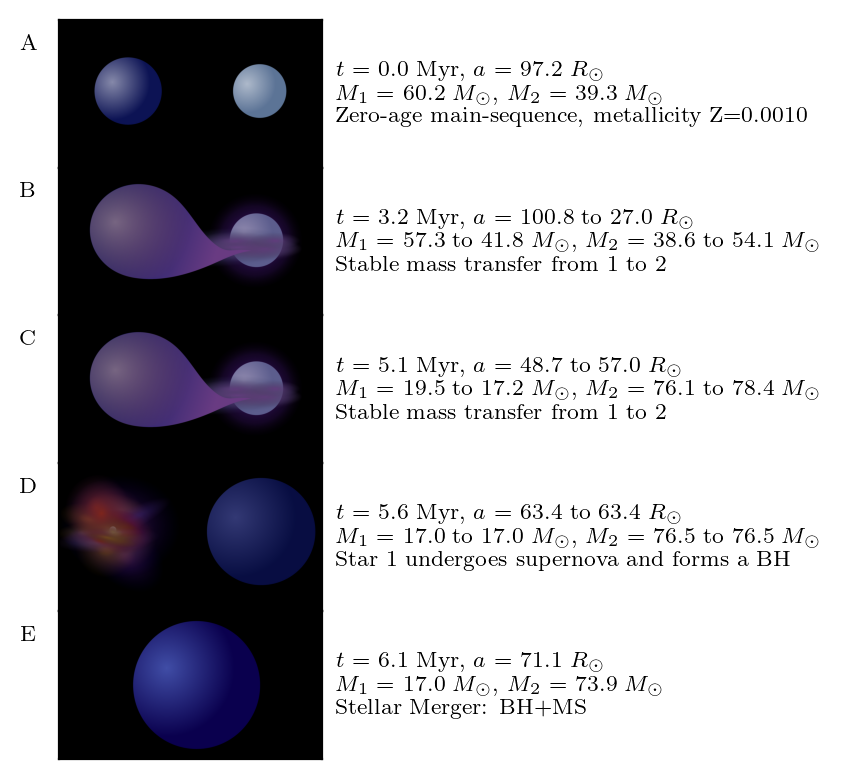

In [103]:
RawData = df_detailed_notides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [104]:
df_sanity_notides = pd.read_csv(notides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_notides = df_sanity_notides.rename(columns=lambda x: x.strip())

df_sanity_notides['SemiMajorAxis_Rsun'] = (df_sanity_notides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_notides['Period1'] = (2 * np.pi / (df_sanity_notides['Omega1'].values / u.yr)).to(u.day)
df_sanity_notides['Period2'] = (2 * np.pi / (df_sanity_notides['Omega2'].values / u.yr)).to(u.day)
df_sanity_notides['Period_orb'] = (2 * np.pi / (df_sanity_notides['Omega'].values / u.yr)).to(u.day)

df_sanity_notides_short = df_sanity_notides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [105]:
st_change_idx = np.where((df_sanity_notides_short['StellarType_1'] != df_sanity_notides_short['StellarType_1'].shift()) | (df_sanity_notides_short['StellarType_2'] != df_sanity_notides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_notides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,60.2175,39.2885,8.355250,6.62771,0.000000e+00,40.5579,0,22.7830,0.000000e+00,4.745290,0,3.39510,97.164860,6.594850e-01,1,1,inf,inf,11.121773,0,0.000,753.012,0.00000,0.00000,4.708490e-07,1.588990e-07,4.708490e-07,1.588990e-07,0,0,0.000000e+00,0,1.223870e-07,2.546430e-08
1980,5.09241,19.5392,76.1228,10.596200,16.64690,0.000000e+00,17.1986,0,38.6099,0.000000e+00,1.305580,0,2.87160,48.630167,0.000000e+00,1,1,inf,0.933078,4.016292,0,112.208,454.394,0.00000,0.00000,6.154200e-11,-6.384060e-08,6.154200e-11,-6.384060e-08,0,0,0.000000e+00,0,8.782530e-07,-1.005600e-03
1981,5.09241,19.5391,76.1195,8.803050,16.64650,2.737090e-183,17.1986,0,38.6080,1.150970e-91,1.305580,0,2.87151,48.638768,0.000000e+00,2,1,inf,0.933260,4.017424,0,112.176,454.420,0.00000,0.00000,1.553950e-10,-6.380560e-08,1.553950e-10,-6.380560e-08,0,0,3.123800e-96,0,4.180410e-07,-1.004980e-03
2322,5.09846,19.5387,76.1011,13.119800,16.69380,4.181230e-148,17.1986,0,38.5621,7.088780e-74,1.305580,0,2.86507,48.687151,0.000000e+00,2,1,inf,0.939865,4.023799,0,111.995,454.572,0.00000,0.00000,2.104380e-11,-6.032690e-08,2.104380e-11,-6.032690e-08,0,0,3.107600e-78,0,2.053760e-06,-9.927610e-04
2323,5.09847,17.1986,78.4412,1.305580,16.30430,0.000000e+00,17.1986,0,40.4434,0.000000e+00,1.305580,0,3.01460,57.029108,0.000000e+00,7,1,inf,0.861028,5.101054,0,120.198,446.370,-2.34009,2.34009,0.000000e+00,-1.579370e-07,0.000000e+00,-1.579370e-07,0,0,0.000000e+00,0,8.827800e-11,-1.482810e-03
2610,5.56198,17.0055,76.4961,1.296630,21.12990,0.000000e+00,12.6630,0,36.5656,0.000000e+00,0.000071,0,2.50026,63.310412,0.000000e+00,7,1,inf,1.667333,6.034455,0,101.667,458.655,0.00000,0.00000,0.000000e+00,-1.088750e-09,0.000000e+00,-1.088750e-09,0,0,0.000000e+00,0,5.393890e-11,-4.778490e-04
2611,5.56199,17.0049,76.4898,1.296620,21.12880,0.000000e+00,12.6630,0,36.5622,0.000000e+00,0.000071,0,2.50012,63.330625,0.000000e+00,8,1,inf,1.667927,6.037551,0,101.611,458.689,0.00000,0.00000,0.000000e+00,-1.087720e-09,0.000000e+00,-1.087720e-09,0,0,0.000000e+00,0,5.386000e-11,-4.773050e-04
2619,5.56510,17.0038,76.4801,1.312390,21.17690,0.000000e+00,12.7939,0,36.5386,0.000000e+00,0.000071,0,2.49682,63.361590,0.000000e+00,8,1,inf,1.676737,6.042351,0,101.525,458.739,0.00000,0.00000,0.000000e+00,-1.044020e-09,0.000000e+00,-1.044020e-09,0,0,0.000000e+00,0,5.640300e-11,-4.726940e-04
2620,5.56535,17.0038,76.4789,0.000072,21.18070,0.000000e+00,17.0038,0,36.5365,0.000000e+00,0.000072,0,2.49654,63.365461,2.237730e-16,14,1,inf,1.677485,6.042924,0,101.514,458.749,0.00000,0.00000,0.000000e+00,-1.040510e-09,0.000000e+00,-1.040510e-09,0,0,0.000000e+00,0,5.135540e-28,-4.722880e-04


### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000042   Zero-age main-sequence, metallicity Z=0.0010   60.217     1     39.289     1     53.978  0.000
  3.927410   Stable mass transfer from 1 to 2   43.845     1     50.328     1     53.324  0.000
  4.015709   Stable mass transfer from 1 to 2   43.724     1     50.300     1     53.050  0.000
  4.309182   Star 1: MS->HG                    35.357     2     58.601     1     61.268  0.000
  4.310274   Stable mass transfer from 1 to 2   20.425     7     73.531     1    118.417  0.000
  4.310274   Star 1: HG->HeMS                  20.425     7     73.531     1    118.417  0.000
  4.731616   Star 1: HeMS->HeHG                20.167     8     72.808     1    119.501  0.000
  4.733026   Star 1 undergoes supernova and forms a BH   20.167    14     72.805     1    119.511  0.000
  6.480355   Star 2: MS->HG                    20.167    14     67.436     2    123.474  0.000
  6.480960   Stable mass t

(<Figure size 900x480 with 8 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1730b8050>])

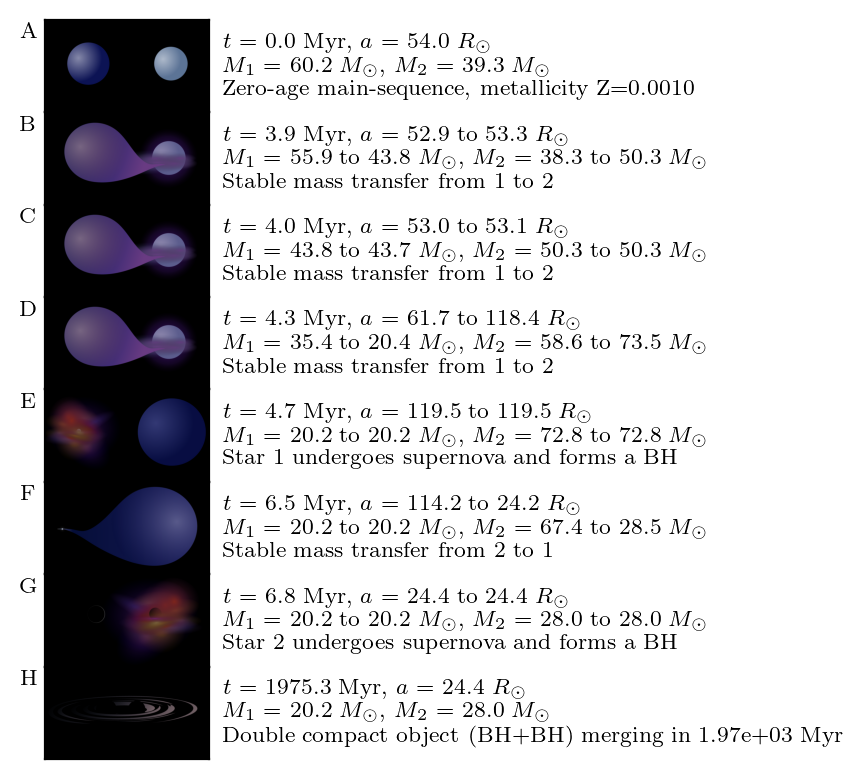

In [108]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [109]:
df_detailed_perfect['Period(1)'] = (2 * np.pi / (df_detailed_perfect['Omega(1)'].values / u.s)).to(u.day)
df_detailed_perfect['Period(2)'] = (2 * np.pi / (df_detailed_perfect['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_perfect['Mass(1)'].values * u.M_sun + df_detailed_perfect['Mass(2)'].values * u.M_sun) / (df_detailed_perfect['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_perfect['Omega_Orb'] = omega_orb.value
df_detailed_perfect['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_perfect_short = df_detailed_perfect[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [33]:
# st_change_idx = np.where((df_detailed_perfect_short['Stellar_Type(1)'] != df_detailed_perfect_short['Stellar_Type(1)'].shift()) | (df_detailed_perfect_short['Stellar_Type(2)'] != df_detailed_perfect_short['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_perfect_short.iloc[st_changes_with_buffer]


In [34]:
df_dco_perfect

,SEED,SemiMajorAxis@DCO,Eccentricity@DCO,Mass(1),Stellar_Type(1),Mass(2),Stellar_Type(2),Coalescence_Time,Time,Merges_Hubble_Time,Recycled_NS(1),Recycled_NS(2),Record_Type
0,1135,0.056323,0.0,11.874137,14,16.548666,14,579.332189,9.285364,1,0,0,1


In [110]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

In [111]:
df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)


df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

In [112]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]


,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,60.2175,39.2885,8.355250,6.627710,0.000000e+00,40.5579,0.000000e+00,22.7830,0.000000e+00,4.745290,0.000000e+00,3.395100,53.978017,0,1,1,4.605054,4.605054,4.605054,4.530740e+00,1.860040e+00,746.621,0.000000,0.0000,4.708490e-07,1.588990e-07,4.708490e-07,1.588990e-07,0,0,0.000000e+00,0.000000e+00,1.223870e-07,2.546430e-08
1710,4.30918,35.3574,58.6010,16.032500,11.137300,0.000000e+00,20.4254,0.000000e+00,30.3968,0.000000e+00,1.449610,0.000000e+00,2.939420,61.267607,0,1,1,5.730772,5.730772,5.730772,7.871020e+00,6.295270e+00,716.904,0.000000,0.0000,-8.963510e-20,3.508980e-21,-8.963510e-20,3.508980e-21,0,0,0.000000e+00,0.000000e+00,-6.370800e-14,5.896890e-19
1711,4.30918,35.3572,58.6006,14.993200,11.137200,3.258270e-200,20.4254,0.000000e+00,30.3966,5.512030e-100,1.449610,0.000000e+00,2.939400,62.139347,0,2,1,5.853556,5.853556,5.853556,2.922480e+00,6.163140e+00,721.980,0.000000,0.0000,-3.189050e-11,9.926610e-22,-3.189050e-11,9.926610e-22,0,0,-2.160290e-104,0.000000e+00,-1.239980e-05,1.668180e-19
1939,4.31027,35.3567,58.5998,20.727400,11.139900,2.618410e-167,20.4254,0.000000e+00,30.3920,2.224160e-83,1.449610,0.000000e+00,2.938580,61.671437,0,2,1,5.787584,5.787584,5.787584,5.578480e+00,6.236290e+00,719.241,0.000000,0.0000,1.591240e-20,7.565780e-25,1.591240e-20,7.565780e-25,0,0,7.767240e-91,0.000000e+00,1.141170e-13,1.277120e-22
1940,4.31027,20.4254,73.5311,1.449610,11.330000,0.000000e+00,20.4254,0.000000e+00,43.6250,0.000000e+00,1.449610,0.000000e+00,3.916310,118.416918,0,7,1,15.398931,15.398931,15.398931,1.383380e-02,3.042320e+00,722.458,-14.931300,14.9313,0.000000e+00,-5.225580e-05,0.000000e+00,-5.225580e-05,0,0,0.000000e+00,0.000000e+00,-1.428070e-11,-1.765320e-03
2081,4.73161,20.1672,72.8077,1.438440,12.400900,0.000000e+00,15.3619,0.000000e+00,40.8137,0.000000e+00,0.000071,0.000000e+00,3.493500,119.501110,0,7,1,15.693140,15.693140,15.693140,1.319720e-02,3.541090e+00,713.269,0.000000,0.0000,0.000000e+00,1.354950e-18,0.000000e+00,1.354950e-18,0,0,0.000000e+00,0.000000e+00,-5.306650e-19,2.600870e-16
2082,4.73162,20.1672,72.8050,0.000086,12.400700,0.000000e+00,20.1672,0.000000e+00,40.8117,0.000000e+00,0.000086,0.000000e+00,3.493400,119.510571,0,14,1,15.695287,15.695287,15.695287,1.865180e-10,3.540360e+00,713.281,0.000000,0.0000,0.000000e+00,3.083590e-20,0.000000e+00,3.083590e-20,0,0,0.000000e+00,0.000000e+00,-8.794540e-08,5.918910e-18
3423,6.48035,20.1672,67.4358,0.000086,25.671500,0.000000e+00,20.1672,0.000000e+00,28.3503,0.000000e+00,0.000086,0.000000e+00,1.768640,123.473829,0,14,1,16.980011,16.980011,16.980011,1.724050e-10,1.299030e+01,691.817,0.000000,0.0000,0.000000e+00,-2.235320e-22,0.000000e+00,-2.235320e-22,0,0,0.000000e+00,0.000000e+00,-5.021430e-47,-7.515360e-15
3424,6.48036,20.1672,67.4350,0.000086,24.762100,0.000000e+00,20.1672,5.036220e-222,28.3503,0.000000e+00,0.000086,8.791490e-111,1.768640,125.667372,0,14,2,17.434597,17.434597,17.434597,1.679100e-10,6.875370e+00,697.930,0.000000,0.0000,0.000000e+00,-9.363200e-14,0.000000e+00,-9.363200e-14,0,0,0.000000e+00,-inf,-4.293540e-41,-2.275380e-06
3884,6.48096,20.1672,67.4335,0.000086,55.450600,0.000000e+00,20.1672,4.938760e-140,28.4686,0.000000e+00,0.000086,2.032430e-69,1.773110,114.222501,0,14,2,15.108086,15.108086,15.108086,1.937670e-10,3.942030e+01,665.381,0.000000,0.0000,0.000000e+00,4.979290e-22,0.000000e+00,4.979290e-22,0,0,0.000000e+00,1.566080e-76,-3.909550e-48,1.684230e-11


# CE binary not able to spin up

In [148]:
notides_DataPath = 'sim_data/ce_notides'
tides_DataPath = 'sim_data/ce_realistic'
perfect_DataPath = 'sim_data/ce_perfect'
# perfect_DataPath = 'sim_data/ce_z77'

# # --------------

df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000051   Zero-age main-sequence, metallicity Z=0.0015   42.439     1     40.690     1   1001.538  0.206
  5.150362   Star 1: MS->HG                    39.891     2     38.493     1   1062.166  0.206
  5.155980   Star 1: HG->CHeB                  39.517     4     38.489     1   1067.312  0.206
  5.290269   Star 1: CHeB->HeMS                14.949     7     38.402     1   1560.539  0.206
  5.295147   Star 2: MS->HG                    14.948     7     38.397     2   1560.729  0.206
  5.301072   Star 2: HG->CHeB                  14.946     7     38.374     4   1561.451  0.206
  5.433927   Common envelope initiated by 2    14.896     7     14.201     7      4.747  0.000
  5.433927   Star 2: CHeB->HeMS                14.896     7     14.201     7      4.747  0.000
  5.662532   Star 1: HeMS->HeHG                14.797     8     14.125     7      4.660  0.000
  5.671464   Star 1 undergoes supernova

(<Figure size 900x480 with 5 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x173ba21d0>])

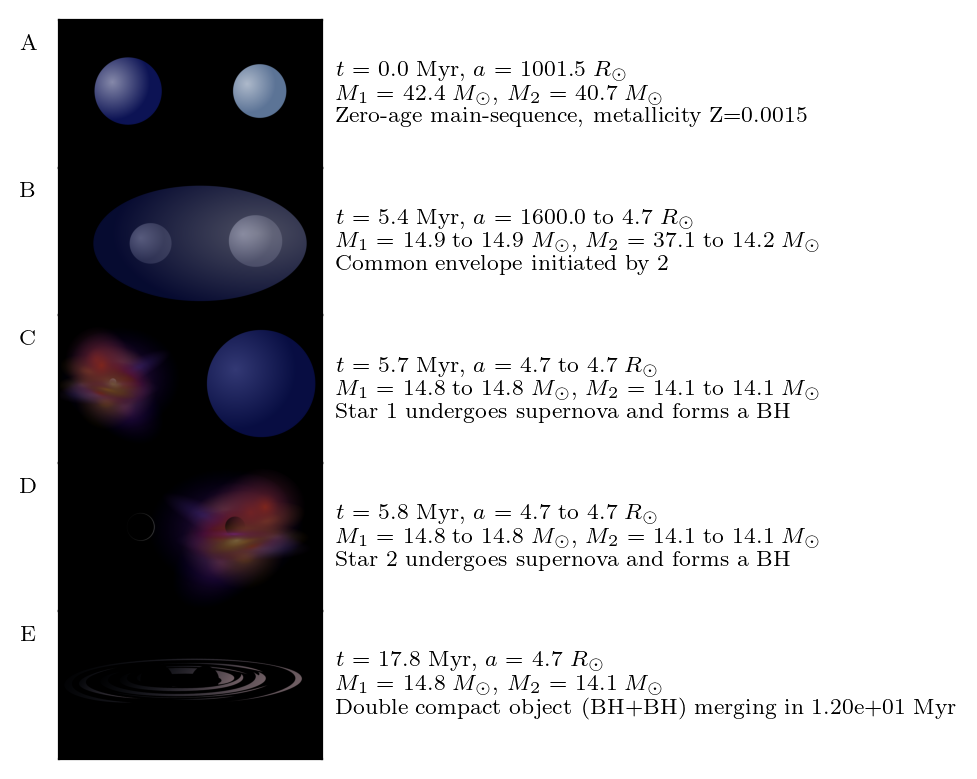

In [144]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [145]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())

df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)

df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

df_sanity_tides.iloc[np.where(df_sanity_tides['StellarType_2'] == 7)]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
11644,196867,5.43391,0.000020,7,7,36.6152,36.6152,36.6152,36.6105,1.781060e-19,0.000095,2.277060e-17,0.004599,10330.2,10334.1,3.352700e-15,1.784000e+00,5.114590e-13,103.308,0.000000e+00,0.000000e+00,14.8964,1.284120,5.312330e-05,5.312330e-05,14.2013,1.20398,0.000045,0.000045,0.022080,0.022075,1.075260e-06,6.545610e-05,1.075260e-06,6.545610e-05,0.000007,4.156200e-04,0.000020,1.225390e-03,1.075260e-06,6.545610e-05,1.075260e-06,6.545610e-05,0.000007,4.156200e-04,0.000020,1.225390e-03,0,0,0,0,0,0,0,0,11.0391,0.583657,12.3351,0.903698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.652030e+05,299434.0,21.693600,21.3189,-0.000006,-3.127940e-04,100.5970,5.825370e+03,-0.0,-0.000000e+00,7.059010e-07,inf,1.773310e-08,1.773310e-08,0.000000,0.000000e+00,0,-22.9376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.462700e-08,3.209180e-08,4.462700e-08,3.209180e-08,2.833640e-07,2.037700e-07,8.354520e-07,6.007820e-07,-2.675000e-07,-1.533560e-07,-0.000000e+00,-0.000000e+00,4.175110e+00,2.856060,4.746727,1.286398e+03,22.214479,0.222074
11645,196867,5.43393,0.003676,7,7,36.6120,36.6120,36.6073,36.6026,9.471040e-05,0.000192,4.596980e-03,0.009197,10332.3,10336.3,1.783200e+00,3.614580e+00,1.032710e+02,206.601,0.000000e+00,0.000000e+00,14.8949,1.284050,5.311270e-05,5.311270e-05,14.2002,1.20394,0.000045,0.000045,0.022076,0.022071,1.074950e-06,6.545980e-05,1.073960e-06,6.202830e-05,0.000007,4.046580e-04,0.000020,1.203800e-03,1.074950e-06,6.545980e-05,1.073960e-06,6.202830e-05,0.000007,4.046580e-04,0.000020,1.203800e-03,0,0,0,0,0,0,0,0,11.0378,0.583575,12.3338,0.903614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.651460e+05,299397.0,21.693300,21.3187,-0.000006,-3.047450e-04,100.6010,5.676100e+03,-0.0,-0.000000e+00,7.244230e-07,inf,1.820320e-08,1.820320e-08,-0.001450,-1.106900e-03,0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.463620e-08,3.210070e-08,4.459510e-08,3.041790e-08,2.832920e-07,1.984390e-07,8.353670e-07,5.903300e-07,-2.676050e-07,-1.494430e-07,-0.000000e+00,-0.000000e+00,4.177380e+00,2.783490,4.745932,6.349101e+02,11.108046,0.222027
11646,196867,5.43760,0.003677,7,7,36.6088,36.6088,36.5994,36.5947,1.918550e-04,0.000286,9.191780e-03,0.013801,10334.5,10338.4,3.608090e+00,5.373570e+00,2.061160e+02,309.467,0.000000e+00,0.000000e+00,14.8935,1.284850,5.317360e-05,5.317360e-05,14.1991,1.20508,0.000045,0.000045,0.022073,0.022067,9.361500e-07,6.067760e-05,9.344080e-07,5.443590e-05,0.000006,3.651270e-04,0.000018,1.096100e-03,9.361500e-07,6.067760e-05,9.344080e-07,5.443590e-05,0.000006,3.651270e-04,0.000018,1.096100e-03,0,0,0,0,0,0,0,0,10.9977,0.574533,12.2830,0.895900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.660480e+05,300217

In [146]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,42.4389,40.6898,7.118600,6.95058,0.000000e+00,25.2838,0.000000e+00,23.88690,0.000000e+00,3.611420,0.000000e+00,3.492000,1001.538069,2.064970e-01,1,1,inf,inf,402.680656,0.000000e+00,0.000000e+00,2512.8900,0,0.0000,1.175790e-11,1.056020e-11,1.175790e-11,1.056020e-11,0,0,0.000000e+00,0.000000e+00,2.653170e-12,2.263240e-12
1489,5.15036,39.8912,38.4926,18.403400,20.90690,0.000000e+00,13.9537,0.000000e+00,13.53370,0.000000e+00,1.149160,0.000000e+00,1.175110,1062.166385,2.064970e-01,1,1,1.499261e+13,2.003696e+13,452.908653,4.472590e-12,4.167610e-12,2369.7500,0,0.0000,5.497880e-18,3.700150e-18,5.497880e-18,3.700150e-18,0,0,0.000000e+00,0.000000e+00,7.891090e-11,1.245510e-10
1490,5.15036,39.8909,38.4924,17.954300,20.90680,4.111140e-258,13.9537,0.000000e+00,13.53370,7.292960e-129,1.149160,0.000000e+00,1.175100,1062.172836,2.064970e-01,2,1,9.321419e+12,2.003626e+13,452.914909,4.472470e-12,4.167730e-12,2369.7400,0,0.0000,6.220510e-18,3.699960e-18,6.220510e-18,3.699960e-18,0,0,inf,0.000000e+00,7.148240e-11,1.245450e-10
4050,5.15598,39.5170,38.4889,264.971000,21.00820,1.664150e-50,14.2327,0.000000e+00,13.52280,7.347100e-24,1.163150,0.000000e+00,1.172710,1067.312105,2.064970e-01,2,1,2.067098e+15,1.925894e+13,457.307454,4.262480e-12,4.377720e-12,2358.6700,0,0.0000,9.404620e-24,3.459520e-18,9.404620e-24,3.459520e-18,0,0,8.590810e-29,0.000000e+00,3.258200e-06,1.237350e-10
4051,5.15598,39.4775,38.4889,254.796000,21.00830,4.826760e-52,14.2328,0.000000e+00,13.52280,1.204100e-24,1.163160,0.000000e+00,1.172710,1067.851835,2.064970e-01,4,1,1.918568e+15,1.915989e+13,457.770847,4.239870e-12,4.400330e-12,2357.5000,0,0.0000,1.140810e-23,3.450130e-18,1.140810e-23,3.450130e-18,0,0,1.336320e-29,0.000000e+00,2.774100e-06,1.234020e-10
8056,5.29019,14.9493,38.4019,1.242470,19.12910,0.000000e+00,14.9491,0.000000e+00,13.26300,0.000000e+00,1.242470,0.000000e+00,1.115630,1560.537811,2.064970e-01,4,1,2.319492e+18,8.071969e+12,977.632414,1.037010e-19,8.640200e-12,1301.6800,0,0.0000,0.000000e+00,4.772770e-19,0.000000e+00,4.772770e-19,0,0,0.000000e+00,0.000000e+00,4.801350e-17,1.117680e-11
8057,5.29027,14.9493,38.4018,1.242510,19.10980,0.000000e+00,12.9275,0.000000e+00,13.26280,0.000000e+00,0.920579,0.000000e+00,1.115590,1560.542112,2.064970e-01,7,1,1.104007e+18,8.055733e+12,977.632414,1.037560e-19,8.640200e-12,1301.6800,0,0.0000,7.576030e-14,4.795500e-19,7.576030e-14,4.795500e-19,0,0,0.000000e+00,0.000000e+00,4.801870e-17,1.113180e-11
8124,5.29515,14.9477,38.3971,1.244070,17.87360,0.000000e+00,12.8553,0.000000e+00,13.25270,0.000000e+00,0.909626,0.000000e+00,1.113490,1560.729190,2.064970e-01,7,1,1.074482e+18,7.046352e+12,977.869858,1.068630e-19,8.640200e-12,1301.5300,0,0.0000,6.806110e-14,6.589170e-19,6.806110e-14,6.589170e-19,0,0,0.000000e+00,0.000000e+00,4.822120e-17,8.511970e-12
8125,5.29515,14.9476,38.3967,1.244070,17.44980,0.000000e+00,12.8552,5.325240e-256,13.25270,0.000000e+00,0.909620,8.202680e-128,1.113490,1560.742092,2.064970e-01,7,2,1.072599e+18,4.417828e+12,977.882358,1.070490e-19,8.640200e-12,1301.5200,0,0.0000,6.805640e-14,7.428930e-19,6.805640e-14,7.428930e-19,0,0,0.000000e+00,inf,4.821800e-17,7.732420e-12
10575,5.30107,14.9456,38.3744,1.245960,229.48600,0.000000e+00,12.7681,2.393010e-54,13.51770,0.000000e+00,0.896272,7.690460e-26,1.127060,1561.451698,2.064970e-01,7,2,1.038902e+18,7.519835e+14,978.774868,1.108430e-19,8.640200e-12,1301.1900,0,0.0000,5.952070e-14,2.046160e-24,5.952070e-14,2.046160e-24,0,0,0.000000e+00,3.551130e-31,4.838500e-17,2.305400e-07


In [147]:
st_labels[4]

'CHeB'

#### Breakdown by tidal mechanism

In [23]:
# Load full data for tidal breakdown
rc = df_sanity_tides["R1_core"].values * u.R_sun              # Rsol
R = df_sanity_tides["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity_tides["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint = R - Renv

rc2 = df_sanity_tides["R2_core"].values * u.R_sun              # Rsol
R2 = df_sanity_tides["R2"].values * u.R_sun                    # Rsol
Renv2 = df_sanity_tides["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2 = R2 - Renv2

L = df_sanity_tides["Lum_1"].values * u.L_sun                 # Lsol
L2 = df_sanity_tides["Lum_2"].values * u.L_sun                 # Lsol

M = df_sanity_tides["M1"].values * u.M_sun                    # Msol
Mc = df_sanity_tides["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity_tides["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity_tides["M2"].values * u.M_sun                   # Msol
Mc2 = df_sanity_tides["M2_core"].values * u.M_sun              # Msol
Menv2 = df_sanity_tides["M2_conv_env"].values * u.M_sun        # Msol


I1 = df_sanity_tides["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity_tides["tau_conv1"].values * u.yr                # yr
tau_conv2 = df_sanity_tides["tau_conv2"].values * u.yr                # yr


omega_orb = df_sanity_tides["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity_tides["Omega1_before"].values / u.yr   # 1/yr
omega_spin2 = df_sanity_tides["Omega2_before"].values / u.yr   # 1/yr

sma = df_sanity_tides["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity_tides["ecc_before"].values                           # 1
period_orb = 2 * np.pi / df_sanity_tides["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk10 = df_sanity_tides["ImK10_1"].values
Imk12 = df_sanity_tides["ImK12_1"].values
Imk22 = df_sanity_tides["ImK22_1"].values
Imk32 = df_sanity_tides["ImK32_1"].values

Imk10_dyn = df_sanity_tides["ImK10_1_dyn"].values
Imk12_dyn = df_sanity_tides["ImK12_1_dyn"].values
Imk22_dyn = df_sanity_tides["ImK22_1_dyn"].values
Imk32_dyn = df_sanity_tides["ImK32_1_dyn"].values

Imk10_eq = df_sanity_tides["ImK10_1_eq"].values
Imk12_eq = df_sanity_tides["ImK12_1_eq"].values
Imk22_eq = df_sanity_tides["ImK22_1_eq"].values
Imk32_eq = df_sanity_tides["ImK32_1_eq"].values

Imk10_2 = df_sanity_tides["ImK10_2"].values
Imk12_2 = df_sanity_tides["ImK12_2"].values
Imk22_2 = df_sanity_tides["ImK22_2"].values
Imk32_2 = df_sanity_tides["ImK32_2"].values

Imk10_2_dyn = df_sanity_tides["ImK10_2_dyn"].values
Imk12_2_dyn = df_sanity_tides["ImK12_2_dyn"].values
Imk22_2_dyn = df_sanity_tides["ImK22_2_dyn"].values
Imk32_2_dyn = df_sanity_tides["ImK32_2_dyn"].values

Imk10_2_eq = df_sanity_tides["ImK10_2_eq"].values
Imk12_2_eq = df_sanity_tides["ImK12_2_eq"].values
Imk22_2_eq = df_sanity_tides["ImK22_2_eq"].values
Imk32_2_eq = df_sanity_tides["ImK32_2_eq"].values

dadt = df_sanity_tides["dadt1"].values * u.AU / u.yr
dOmegadt = df_sanity_tides["dOmegadt1"].values / u.yr**2
dedt1 = df_sanity_tides["dedt1"].values / u.yr


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity_tides["Time"].values * 1e6 * u.yr          # yr
st1 = df_sanity_tides["StellarType_1"].values
st2 = df_sanity_tides["StellarType_2"].values

rc_AU = df_sanity_tides["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity_tides["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity_tides["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     


rc_AU2 = df_sanity_tides["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2 = df_sanity_tides["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2 = df_sanity_tides["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2 = R_AU2 - Renv_AU2                 
Mint2 = M2 - Mc2 - Menv2    

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

In [43]:
print("Equilibrium tides from turbulent viscosity:")
Imk22_eq[st_changes_with_buffer][1:]

Equilibrium tides from turbulent viscosity:


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [63]:
print("IGW dissipation from convective core -- radiative envelope boundary:")
E2_kushnir = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.)
l=2
m=2
imk22_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk22_core_gw[(rc_AU/R_AU < frac_limit) | (Mc/M < frac_limit) | (Menv/M > frac_limit) | (Renv/R_AU > frac_limit)] = 0.0
imk22_core_gw[np.isnan(imk22_core_gw)] = 0.0
imk22_core_gw[st_changes_with_buffer][1:]

0.1 * (2./3.) * (R_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)

IGW dissipation from convective core -- radiative envelope boundary:


<Quantity [2.06015729e-08, 2.06009626e-08, 2.07079699e-08, ...,
           1.39643338e-21, 1.39643338e-21, 1.39642555e-21]>

In [37]:
print("IGW dissipation from radiative zone -- convective shell boundary:")

dNlnr_cbrt = (G_AU_Msol_yr * Mint / (Rint_AU**2 * (R_AU - Rint_AU)))**(1/3)

alpha = Rint_AU/R_AU
beta = Mint/M

# one_minus_beta = 1-beta
one_minus_beta = Menv/M

# gamma = alpha**3 * (1-beta) / (beta * (1 - alpha**3))
rho_conv = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3))
rho_rad = Mint / (4 * np.pi * (Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

Epsilon = alpha**11 * (one_minus_beta) * (1-gamma)**2 * (2*alpha/3 - 1)**2 / (beta**2 * (1-alpha**3) * (1-alpha)**2)


l=2
m=2
imk22_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (2*(2+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk22_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk22_env_gw)
imk22_env_gw[(Renv_AU/R_AU < frac_limit) | (Menv/M < frac_limit)] = 0.0
imk22_env_gw[np.isnan(imk22_env_gw)] = 0.0

imk22_env_gw[st_changes_with_buffer][1:]

IGW dissipation from radiative zone -- convective shell boundary:


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0.]>

In [42]:
print("Dynamical tides from inertial wave dissipation:")
alpha = Rint_AU/R_AU
beta = Mint/M
one_minus_beta = Menv/M

rho_conv = Menv / ((R_AU**3 - Rint_AU**3))
rho_rad = Mint / ((Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

eps = omega_spin / np.sqrt(G_AU_Msol_yr * M / R_AU**3)

b1 = (1 + 2*alpha + 3*alpha**2 + (3/2)*alpha**3)
b2 = 1 + ((1-gamma) / gamma) * alpha**3
b3 = 1 + (3*gamma/2) + ((5*alpha**3)/(2*gamma))*(1 + gamma/2 - (3*gamma**2)/2) - (9/4)*(1-gamma)*alpha**5
imk22_inertial = (100 * np.pi / 63) * eps**2 * (alpha**5 / (1 - alpha**5)) * (1-gamma)**2 * (1-alpha)**4 * b1**2 * b2 * b3**(-2)

imk22_inertial[((Renv_AU/R_AU < frac_limit) & (Menv/M < frac_limit)) | (omega_orb > 2*omega_spin) | (Mint/M < frac_limit)] = 0.0
imk22_inertial = np.sign(omega_orb - omega_spin) * np.abs(imk22_inertial)
imk22_inertial[np.isnan(imk22_inertial)] = 0.0

imk22_inertial[st_changes_with_buffer][1:]

Dynamical tides from inertial wave dissipation:


<Quantity [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0.]>

### Notides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000051   Zero-age main-sequence, metallicity Z=0.0015   42.439     1     40.690     1   1001.538  0.206
  5.150362   Star 1: MS->HG                    39.891     2     38.493     1   1062.166  0.206
  5.155980   Star 1: HG->CHeB                  39.517     4     38.489     1   1067.312  0.206
  5.290269   Star 1: CHeB->HeMS                14.949     7     38.402     1   1560.539  0.206
  5.295147   Star 2: MS->HG                    14.948     7     38.397     2   1560.729  0.206
  5.301072   Star 2: HG->CHeB                  14.946     7     38.374     4   1561.451  0.206
  5.433927   Common envelope initiated by 2    14.896     7     14.201     7      4.748  0.000
  5.433927   Star 2: CHeB->HeMS                14.896     7     14.201     7      4.748  0.000
  5.662532   Star 1: HeMS->HeHG                14.797     8     14.125     7      4.777  0.000
  5.671464   Star 1 undergoes supernova

(<Figure size 900x480 with 5 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1736f7f10>])

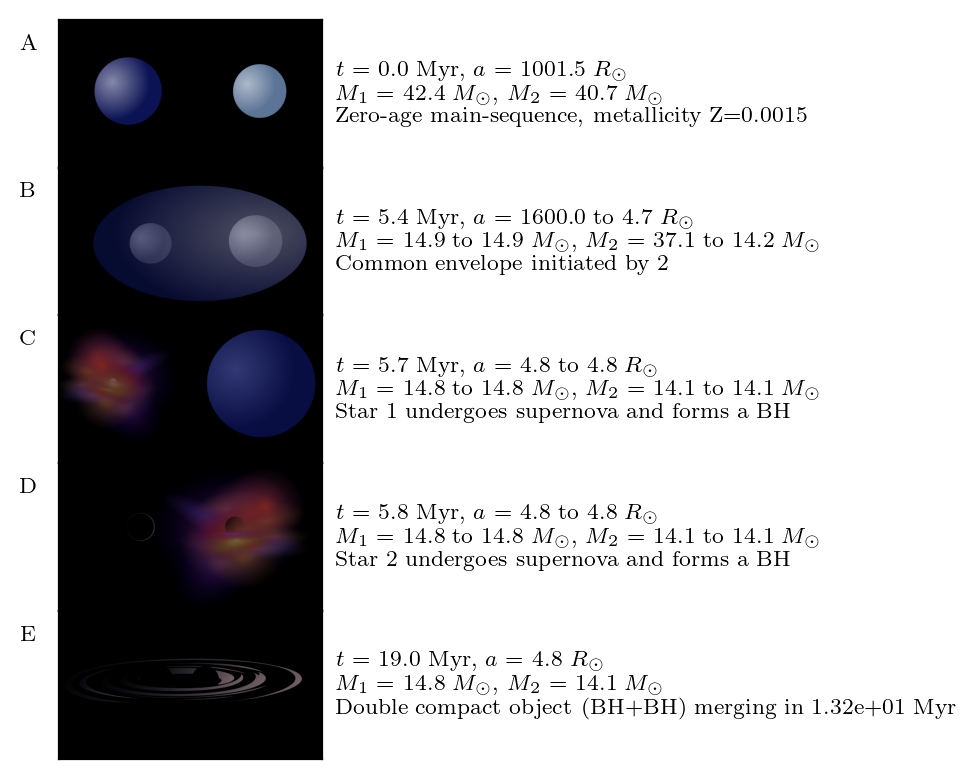

In [149]:
RawData = df_detailed_notides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [150]:
df_sanity_notides = pd.read_csv(notides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_notides = df_sanity_notides.rename(columns=lambda x: x.strip())

df_sanity_notides['SemiMajorAxis_Rsun'] = (df_sanity_notides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_notides['Period1'] = (2 * np.pi / (df_sanity_notides['Omega1'].values / u.yr)).to(u.day)
df_sanity_notides['Period2'] = (2 * np.pi / (df_sanity_notides['Omega2'].values / u.yr)).to(u.day)
df_sanity_notides['Period_orb'] = (2 * np.pi / (df_sanity_notides['Omega'].values / u.yr)).to(u.day)

df_sanity_notides_short = df_sanity_notides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [151]:
st_change_idx = np.where((df_sanity_notides_short['StellarType_1'] != df_sanity_notides_short['StellarType_1'].shift()) | (df_sanity_notides_short['StellarType_2'] != df_sanity_notides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_notides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,42.4389,40.6898,7.118600,6.95058,0.000000e+00,25.2838,0.000000e+00,23.88690,0.000000e+00,3.611420,0.000000e+00,3.492000,1001.538069,2.064970e-01,1,1,inf,inf,402.680656,0,0,2512.8900,0,0.0000,1.175790e-11,1.056020e-11,1.175790e-11,1.056020e-11,0,0,0.000000e+00,0.000000e+00,2.653170e-12,2.263240e-12
1489,5.15036,39.8912,38.4926,18.403400,20.90690,0.000000e+00,13.9537,0.000000e+00,13.53370,0.000000e+00,1.149160,0.000000e+00,1.175110,1062.166385,2.064970e-01,1,1,inf,inf,452.908653,0,0,2369.7500,0,0.0000,5.497880e-18,3.700150e-18,5.497880e-18,3.700150e-18,0,0,0.000000e+00,0.000000e+00,7.891090e-11,1.245510e-10
1490,5.15036,39.8909,38.4924,17.954300,20.90680,4.111140e-258,13.9537,0.000000e+00,13.53370,7.292960e-129,1.149160,0.000000e+00,1.175100,1062.172836,2.064970e-01,2,1,inf,inf,452.914909,0,0,2369.7400,0,0.0000,6.220510e-18,3.699960e-18,6.220510e-18,3.699960e-18,0,0,inf,0.000000e+00,7.148240e-11,1.245450e-10
4050,5.15598,39.5170,38.4889,264.971000,21.00820,1.664150e-50,14.2327,0.000000e+00,13.52280,7.347100e-24,1.163150,0.000000e+00,1.172710,1067.312105,2.064970e-01,2,1,inf,inf,457.307454,0,0,2358.6700,0,0.0000,9.404620e-24,3.459520e-18,9.404620e-24,3.459520e-18,0,0,8.590810e-29,0.000000e+00,3.258200e-06,1.237350e-10
4051,5.15598,39.4775,38.4889,254.796000,21.00830,4.826760e-52,14.2328,0.000000e+00,13.52280,1.204100e-24,1.163160,0.000000e+00,1.172710,1067.851835,2.064970e-01,4,1,inf,inf,457.770847,0,0,2357.5000,0,0.0000,1.140810e-23,3.450130e-18,1.140810e-23,3.450130e-18,0,0,1.336320e-29,0.000000e+00,2.774100e-06,1.234020e-10
8056,5.29019,14.9493,38.4019,1.242470,19.12910,0.000000e+00,14.9491,0.000000e+00,13.26300,0.000000e+00,1.242470,0.000000e+00,1.115630,1560.537811,2.064970e-01,4,1,inf,inf,977.632414,0,0,1301.6800,0,0.0000,0.000000e+00,4.772770e-19,0.000000e+00,4.772770e-19,0,0,0.000000e+00,0.000000e+00,4.801350e-17,1.117680e-11
8057,5.29027,14.9493,38.4018,1.242510,19.10980,0.000000e+00,12.9275,0.000000e+00,13.26280,0.000000e+00,0.920579,0.000000e+00,1.115590,1560.542112,2.064970e-01,7,1,inf,inf,977.632414,0,0,1301.6800,0,0.0000,7.576030e-14,4.795500e-19,7.576030e-14,4.795500e-19,0,0,0.000000e+00,0.000000e+00,4.801870e-17,1.113180e-11
8124,5.29515,14.9477,38.3971,1.244070,17.87360,0.000000e+00,12.8553,0.000000e+00,13.25270,0.000000e+00,0.909626,0.000000e+00,1.113490,1560.729190,2.064970e-01,7,1,inf,inf,977.869858,0,0,1301.5300,0,0.0000,6.806110e-14,6.589170e-19,6.806110e-14,6.589170e-19,0,0,0.000000e+00,0.000000e+00,4.822120e-17,8.511970e-12
8125,5.29515,14.9476,38.3967,1.244070,17.44980,0.000000e+00,12.8552,5.325240e-256,13.25270,0.000000e+00,0.909620,8.202680e-128,1.113490,1560.742092,2.064970e-01,7,2,inf,inf,977.882358,0,0,1301.5200,0,0.0000,6.805640e-14,7.428930e-19,6.805640e-14,7.428930e-19,0,0,0.000000e+00,inf,4.821800e-17,7.732420e-12
10575,5.30107,14.9456,38.3744,1.245960,229.48600,0.000000e+00,12.7681,2.393010e-54,13.51770,0.000000e+00,0.896272,7.690460e-26,1.127060,1561.451698,2.064970e-01,7,2,inf,inf,978.774868,0,0,1301.1900,0,0.0000,5.952070e-14,2.046160e-24,5.952070e-14,2.046160e-24,0,0,0.000000e+00,3.551130e-31,4.838500e-17,2.305400e-07


### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000073   Zero-age main-sequence, metallicity Z=0.0002   26.708     1     24.138     1    501.638  0.000
  7.302147   Star 1: MS->HG                    26.376     2     23.937     1    506.802  0.000
  7.313064   Star 1: HG->CHeB                  26.375     4     23.936     1    506.197  0.000
  7.879652   Stable mass transfer from 1 to 2    9.959     7     25.019     1   1286.033  0.000
  7.879652   Star 1: CHeB->HeMS                 9.959     7     25.019     1   1286.033  0.000
  8.001234   Star 1: HeMS->HeHG                 9.953     8     25.011     1   1286.533  0.000
  8.029444   Star 1 undergoes supernova and forms a BH    9.951    14     25.009     1   1286.667  0.000
  8.385319   Star 2: MS->HG                     9.951    14     24.986     2   1287.540  0.000
  8.397355   Star 2: HG->CHeB                   9.951    14     24.985     4   1287.212  0.000
  9.106713   Common envelope

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x172757790>])

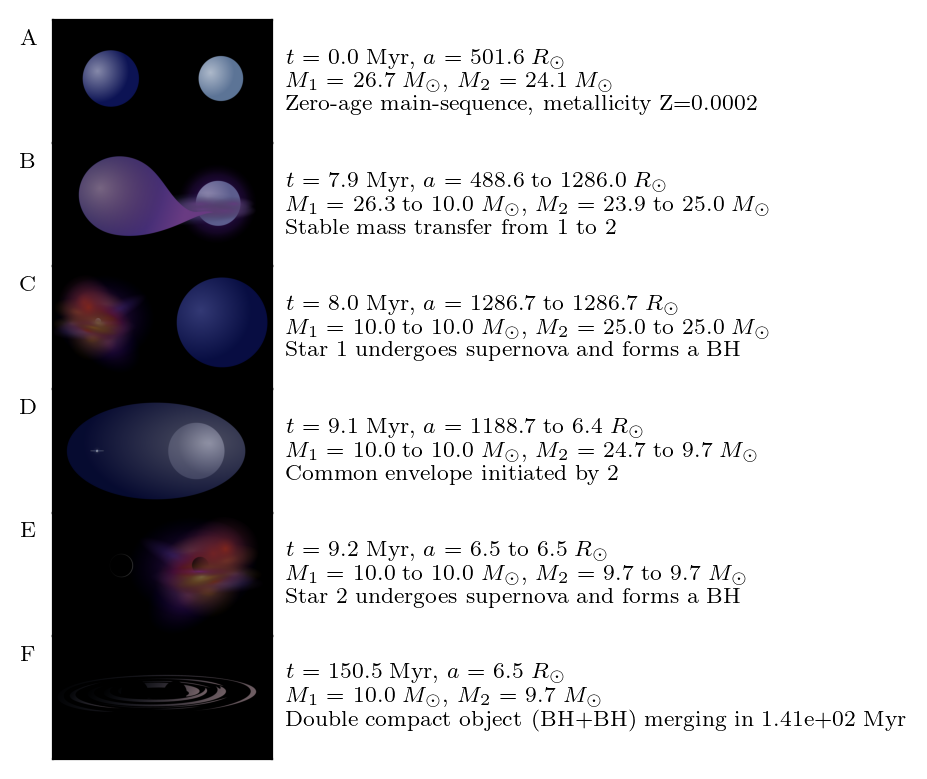

In [65]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [70]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)

df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

df_sanity_perfect.iloc[np.where(df_sanity_perfect['StellarType_2'] == 4)]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
5719,1919508,8.39736,0.001474,14,4,646.737,646.737,646.630,646.630,3.885680e-13,3.885650e-13,0.106414,0.106408,2.53566,2.53566,2.53568,2.53566,2.53580,2.53566,0.0,0,9.9509,0.000042,1.532400e-13,1.532400e-13,24.9847,33.3707,0.041965,0.041965,5.98616,5.98616,0.0,5.313580e-22,0.0,-5.315150e-22,0.0,-1.511760e-32,0.0,5.312000e-22,0.0,5.313580e-22,0.0,-5.315150e-22,0.0,-1.511760e-32,0.0,5.312000e-22,0,0,0,0,0,0,0,0,9.9509,0.000042,7.56913,0.788514,0.0,0.0,5.948750e-139,14.4003,0.0,6.622270e-69,0.0,2.431060e-71,1.000000e-10,244356.0,0.48684,3.848780,-0.0,3.210710e-39,0.0,-4.132340e-36,-0.0,-0.0,1.864440e+31,inf,6.136140e+27,6.136140e+27,0.0,-0.000121,0.0,0.0,0.0,1.792420e-75,0.0,-1.792620e-75,0.0,-1.989420e-79,0.0,1.792230e-75,6.689380e-36,-1.047890e-11,-6.689630e-36,-1.048200e-11,-7.533870e-49,-2.981340e-22,6.689130e-36,1.047580e-11,3.258920e-84,6.331850e-29,-0.0,-0.0,-1.148630e-69,-8.149400e-26,1287.216889,905.063547,905.063547,905.063547
5720,1919508,8.39883,0.001474,14,4,646.736,646.736,646.629,646.630,3.885650e-13,3.885620e-13,0.106403,0.106373,2.53564,2.53564,2.53566,2.53564,2.53636,2.53564,0.0,0,9.9509,0.000042,1.532400e-13,1.532400e-13,24.9845,33.3697,0.041951,0.041951,5.98618,5.98618,0.0,5.347300e-22,0.0,-5.355320e-22,0.0,-1.153080e-30,0.0,5.339280e-22,0.0,5.347300e-22,0.0,-5.355320e-22,0.0,-1.153080e-30,0.0,5.339280e-22,0,0,0,0,0,0,0,0,9.9509,0.000042,7.57353,0.789124,0.0,0.0,5.703210e-139,14.4002,0.0,6.483860e-69,0.0,2.380030e-71,1.000000e-10,244439.0,0.48684,3.849170,-0.0,2.448510e-37,0.0,-3.152350e-34,-0.0,-0.0,2.444830e+29,inf,8.043670e+25,8.043670e+25,0.0,-0.000121,0.0,0.0,0.0,1.755130e-75,0.0,-1.756120e-75,0.0,-9.873130e-79,0.0,1.754140e-75,6.689250e-36,-1.047730e-11,-6.689500e-36,-1.049310e-11,-7.551290e-49,-2.259300e-20,6.689000e-36,1.046160e-11,3.266370e-84,4.797530e-27,-0.0,-0.0,-1.151250e-69,-6.176610e-24,1287.221190,905.070686,905.070686,905.070686
5721,1919508,8.40030,0.001474,14,4,646.735,646.735,646.629,646.629,3.885620e-13,3.885590e-13,0.106368,0.106338,2.53563,2.53563,2.53564,2.53563,2.53634,2.53563,0.0,0,9.9509,0.000042,1.532400e-13,1.532400e-13,24.9844,33.3686,0.041938,0.041938,5.98620,5.98620,0.0,5.381200e-22,0.0,-5.389270e-22,0.0,-1.157590e-30,0.0,5.373140e-22,0.0,5.381200e-22,0.0,-5.389270e-22,0.0,-1.157590e-30,0.0,5.373140e-22,0,0,0,0,0,0,0,0,9.9509,0.000042,7.57792,0.789734,0.0,0.0,5.467940e-139,14.4001,0.0,6.348420e-69,0.0,2.330100e-71,1.000000e-10,244523.0,0.48684,3.849560,-0.0,2.457680e-37,0.0,-3.165160e-34,-0.0,-0.0,2.435710e+29,inf,8.011060e+25,8.011060e+25,0.0,-0.000122,0.0,0.0,0.0,1.718630e-75,0.0,-1.719600e-75,0.0,

In [69]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,26.70760,24.13840,4.800230,4.521210,0.000000e+00,13.53120,0.000000e+00,11.80580,0.000000e+00,2.467860,0.000000e+00,2.263780,501.637764,0,1,1,182.512739,182.512739,182.512739,1.673520e-02,1.341800e-02,867.6380,0.000,0.00000,5.169080e-11,3.846470e-11,5.169080e-11,3.846470e-11,0,0,0.000000e+00,0.000000e+00,2.237830e-12,1.512230e-12
1288,7.30215,26.37570,23.93700,11.701300,10.037000,0.000000e+00,7.98290,0.000000e+00,7.43831,0.000000e+00,0.814986,0.000000e+00,0.890561,506.800686,0,1,1,186.317897,186.317897,186.317897,9.620110e-02,6.423700e-02,858.5840,0.000,0.00000,-1.532980e-24,1.118090e-27,-1.532980e-24,1.118090e-27,0,0,0.000000e+00,0.000000e+00,-2.096420e-18,1.360590e-22
1289,7.30215,26.37560,23.93700,11.495300,10.037000,2.933610e-259,7.98290,0.000000e+00,7.43830,1.487190e-129,0.814986,0.000000e+00,0.890560,506.839392,0,2,1,186.339077,186.339077,186.339077,6.503310e-02,6.422960e-02,858.6130,0.000,0.00000,-8.294350e-18,1.281810e-31,-8.294350e-18,1.281810e-31,0,0,-inf,0.000000e+00,-9.667510e-12,1.559810e-26
2368,7.31306,26.37480,23.93640,35.714000,10.071500,9.053720e-138,8.14255,0.000000e+00,7.43176,2.698940e-68,0.825049,0.000000e+00,0.888525,506.196446,0,2,1,185.985707,185.985707,185.985707,6.208950e-01,6.479320e-02,858.0340,0.000,0.00000,2.091030e-27,5.154410e-31,2.091030e-27,5.154410e-31,0,0,7.315800e-77,0.000000e+00,6.042730e-17,6.595880e-26
2369,7.31306,26.37470,23.93640,35.712200,10.071500,8.956900e-138,8.14255,0.000000e+00,7.43173,2.684340e-68,0.825049,0.000000e+00,0.888522,506.198596,0,4,1,185.988721,185.988721,185.988721,6.208210e-01,6.479220e-02,858.0300,0.000,0.00000,-1.748460e-30,2.358360e-30,-1.748460e-30,2.358360e-30,0,0,-5.101510e-78,0.000000e+00,-5.050400e-20,3.017880e-25
4118,7.87954,26.30450,23.90580,189.173000,12.506800,5.393110e-39,9.95833,0.000000e+00,7.09298,3.560650e-18,1.022830,0.000000e+00,0.783048,488.602515,0,4,1,176.552354,176.552354,176.552354,1.644530e+01,1.051210e-01,840.5110,0.000,0.00000,3.234210e-30,1.225750e-28,3.234210e-30,1.225750e-28,0,0,9.834420e-26,0.000000e+00,5.777350e-14,3.221430e-22
4119,7.87960,9.95851,25.01890,1.022830,11.195800,0.000000e+00,6.45671,0.000000e+00,7.75750,0.000000e+00,0.192225,0.000000e+00,0.881202,1286.032062,0,7,1,903.275278,903.275278,903.275278,5.724570e-05,1.723150e-02,647.3260,-16.346,1.11305,-1.993810e-17,-2.776370e-11,-1.993810e-17,-2.776370e-11,0,0,0.000000e+00,0.000000e+00,-6.246050e-16,-1.122920e-05
4211,8.00123,9.95271,25.01090,0.933968,11.750900,0.000000e+00,6.81332,0.000000e+00,7.67636,0.000000e+00,0.000071,0.000000e+00,0.856557,1286.533087,0,7,1,903.979767,903.979767,903.979767,4.766610e-05,1.896170e-02,646.9950,0.000,0.00000,0.000000e+00,8.101520e-30,0.000000e+00,8.101520e-30,0,0,0.000000e+00,0.000000e+00,-1.598670e-27,6.444010e-24
4212,8.00123,9.95260,25.01080,0.933966,11.750900,0.000000e+00,6.81332,0.000000e+00,7.67630,0.000000e+00,0.000071,0.000000e+00,0.856553,1286.541688,0,8,1,903.994010,903.994010,903.994010,1.503450e-05,1.896110e-02,646.9890,0.000,0.00000,0.000000e+00,6.094340e-32,0.000000e+00,6.094340e-32,0,0,0.000000e+00,0.000000e+00,-8.074160e-17,4.847450e-26
4338,8.02915,9.95090,25.00910,1.067170,11.889200,0.000000e+00,7.34154,0.000000e+00,7.65776,0.000000e+00,0.000071,0.000000e+00,0.850905,1286.666407,0,8,1,904.164966,904.164966,904.164966,1.631250e-05,1.940520e-02,646.8970,0.000,0.00000,0.000000e+00,4.762580e-29,0.000000e+00,4.762580e-29,0,0,0.000000e+00,0.000000e+00,7.365150e-26,4.452440e-23


In [73]:
st_labels[4], st_labels[2]

('CHeB', 'HG')

# CHE Binary

In [163]:
tides_DataPath = 'sim_data/che_realistic'
notides_DataPath = 'sim_data/che_notides'
perfect_DataPath = 'sim_data/che_perfect'

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())


df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())

### Realistic

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000064   Zero-age main-sequence, metallicity Z=0.0003   46.620    16     46.620    16     15.966  0.000
  6.443650   Star 1: CHE->HeMS                 44.673     7     44.673     7     17.133  0.000
  6.443650   Star 2: CHE->HeMS                 44.673     7     44.673     7     17.133  0.000
  6.722919   Star 1: HeMS->HeHG                44.265     8     44.265     8     17.476  0.000
  6.722919   Star 2: HeMS->HeHG                44.265     8     44.265     8     17.476  0.000
  6.722919   Star 1 undergoes supernova and forms a BH   42.049    14     42.049    14     18.462  0.051
  6.722919   Star 2 undergoes supernova and forms a BH   42.049    14     42.049    14     18.462  0.051
122.979542   Double compact object (BH+BH) merging in 1.16e+02 Myr   42.049    14     42.049    14     18.462  0.051
Merges Hubble Time?: [ True]


(<Figure size 900x480 with 4 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x173ebb250>])

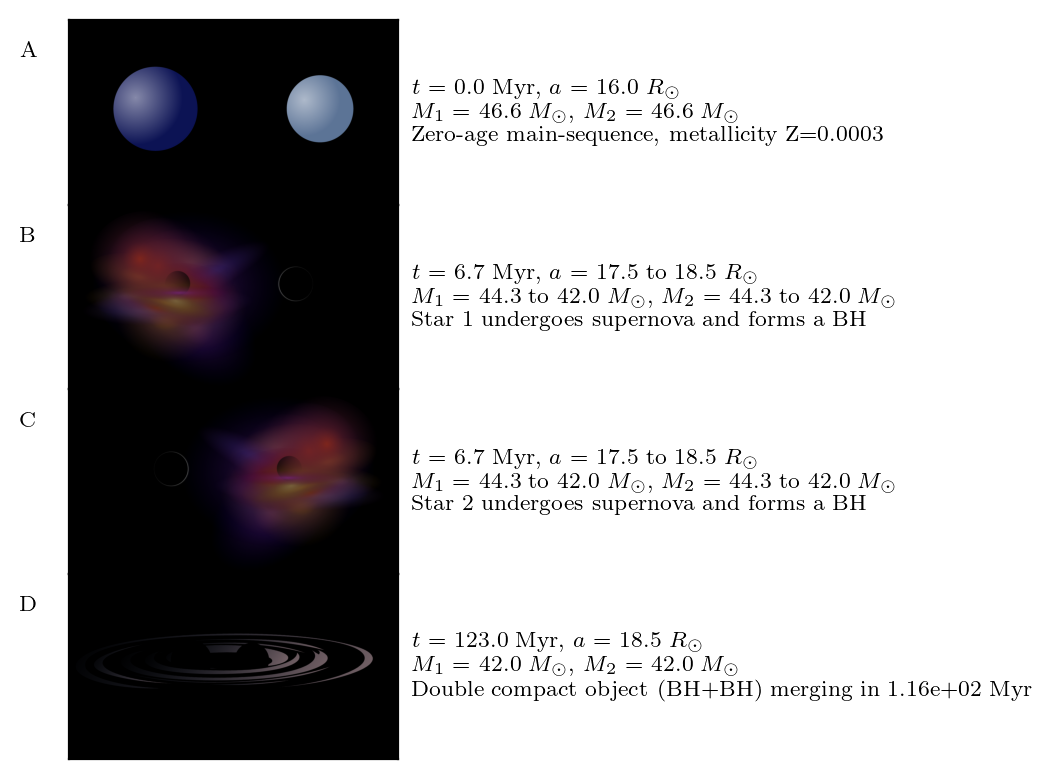

In [157]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [158]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())

df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)

df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

df_sanity_tides.iloc[np.where(df_sanity_tides['StellarType_2'] == 7)]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
103,9976,6.44365,0.013932,7,7,396.888,396.888,374.371,374.371,11.2586,11.2586,11.2586,11.2586,2637.78,2637.78,21513.7,21513.7,21513.7,21513.7,0.0,0.0,44.6572,2.32778,0.000523,0.000523,44.6572,2.32778,0.000523,0.000523,0.079726,0.079726,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,0,0,0,0,44.6572,2.327780,44.6572,2.327780,0,0,0,0,0,0,0,0,1602670.0,1602670.0,23.3206,23.3206,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0,0,inf,inf,inf,inf,-0.015655,-0.015655,0,0,0,0,0,0,0,0,0,0,6.612360e-08,-6.612360e-08,-0.000096,-0.000096,-0.000080,-0.000080,-0.000066,-0.000066,0.000002,0.000002,0.0,0.0,-10.42970,-10.42970,17.143697,0.106673,0.106673,0.870025
104,9976,6.45758,0.007528,7,7,396.815,396.815,374.327,374.355,11.2439,11.2301,11.2439,11.2301,2636.14,2635.55,21415.6,21389.2,21415.6,21389.2,0.0,0.0,44.6484,2.33181,0.000525,0.000525,44.6484,2.33181,0.000525,0.000525,0.079754,0.079766,3.737240e-05,3.737240e-05,-5.342740e-02,-5.342740e-02,-4.458670e-02,-4.458670e-02,-3.672210e-02,-3.672210e-02,3.737240e-05,3.737240e-05,-5.342740e-02,-5.342740e-02,-4.458670e-02,-4.458670e-02,-3.672210e-02,-3.672210e-02,0,0,0,0,0,0,0,0,43.5845,2.215250,43.5845,2.215250,0,0,0,0,0,0,0,0,1638280.0,1638280.0,23.4288,23.4288,1.306870e-03,1.306870e-03,-5.841350e+03,-5.841350e+03,0,0,6.102680e-07,inf,4.512890e-09,4.512890e-09,-0.008712,-0.008712,0,0,0,0,0,0,0,0,0,0,6.645300e-08,-6.645300e-08,-0.000095,-0.000095,-0.000079,-0.000079,-0.000065,-0.000065,0.000002,0.000002,0.0,0.0,-10.38670,-10.38670,17.152255,0.107294,0.107294,0.870761
105,9976,6.46511,0.007538,7,7,396.741,396.741,374.310,374.338,11.2152,11.2014,11.2152,11.2014,2633.88,2633.29,21327.6,21301.3,21327.6,21301.3,0.0,0.0,44.6396,2.33387,0.000526,0.000526,44.6396,2.33387,0.000526,0.000526,0.079795,0.079806,2.937800e-05,2.937800e-05,-4.161130e-02,-4.161130e-02,-3.470320e-02,-3.470320e-02,-2.856050e-02,-2.856050e-02,2.937800e-05,2.937800e-05,-4.161130e-02,-4.161130e-02,-3.470320e-02,-3.470320e-02,-2.856050e-02,-2.856050e-02,0,0,0,0,0,0,0,0,43.0120,2.154170,43.0120,2.154170,0,0,0,0,0,0,0,0,1657300.0,1657300.0,23.4862,23.4862,1.018730e-03,1.018730e-03,-4.543820e+03,-4.543820e+03,0,0,7.832760e-07,inf,5.796610e-09,5.796610e-09,-0.008863,-0.008863,0,0,0,0,0,0,0,0,0,0,6.651510e-08,-6.651510e-08,-0.000094,-0.000094,-0.000079,-0.000079,-0.000065,-0.000065,0.000002,0.000002,0.0,0.0,-10.28770,-10.28770,17.160921,0.107737,0.107737,0.871508
106,9976,6.47265,0.007543,7

In [159]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,46.6202,46.6202,6.787670,6.787670,0,28.7038,0,28.7038,0,3.890410,0,3.890410,15.965535,0.000000,16,16,7.652610e-01,7.652610e-01,0.765258,13.9306,13.9306,385.359,0,0,4.951580e-21,4.951580e-21,4.951580e-21,4.951580e-21,0,0,0,0,5.083980e-22,5.083980e-22
102,6.44365,44.6728,44.6728,6.787670,6.787670,0,16.2579,0,16.2579,0,1.261570,0,1.261570,17.132859,0.000000,16,16,9.052099e-01,9.052099e-01,0.869046,11.2849,11.2849,374.449,0,0,4.992500e-12,4.992500e-12,4.992500e-12,4.992500e-12,0,0,0,0,5.681190e-09,5.681190e-09
103,6.44365,44.6572,44.6572,2.327780,2.327780,0,44.6572,0,44.6572,0,2.327780,0,2.327780,17.143697,0.000000,7,7,1.066731e-01,1.066731e-01,0.870025,11.2586,11.2586,374.371,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-7.984010e-05,-7.984010e-05
145,6.72292,44.2648,44.2648,2.315410,2.315410,0,36.4221,0,36.4221,0,0.000072,0,0.000072,17.475749,0.000000,7,7,1.144571e-01,1.144571e-01,0.899385,10.2905,10.2905,373.008,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-6.301820e-05,-6.301820e-05
146,6.72292,42.0491,42.0491,0.000178,0.000178,0,42.0491,0,42.0491,0,0.000178,0,0.000178,18.461607,0.051302,14,14,2.582808e-09,2.582808e-09,1.001949,10.2739,10.2739,354.496,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-7.249200e-01,-7.249200e-01


### No Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000064   Zero-age main-sequence, metallicity Z=0.0003   46.620    16     46.620    16     15.966  0.000
  6.443650   Star 1: CHE->HeMS                 44.673     7     44.673     7     17.029  0.000
  6.443650   Star 2: CHE->HeMS                 44.673     7     44.673     7     17.029  0.000
  6.722919   Star 1: HeMS->HeHG                44.265     8     44.265     8     17.316  0.000
  6.722919   Star 2: HeMS->HeHG                44.265     8     44.265     8     17.316  0.000
  6.722919   Star 1 undergoes supernova and forms a BH   42.049    14     42.049    14     18.294  0.051
  6.722919   Star 2 undergoes supernova and forms a BH   42.049    14     42.049    14     18.294  0.051
118.802999   Double compact object (BH+BH) merging in 1.12e+02 Myr   42.049    14     42.049    14     18.294  0.051
Merges Hubble Time?: [ True]


(<Figure size 900x480 with 4 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x174012910>])

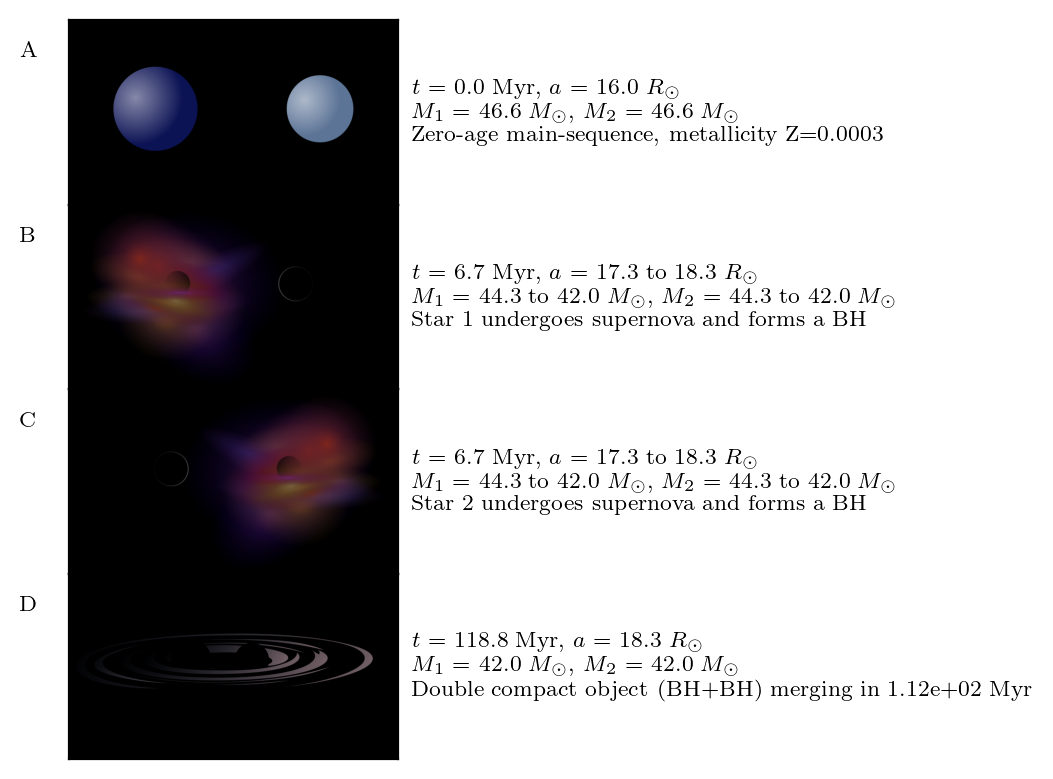

In [160]:
RawData = df_detailed_notides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_notides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [161]:
df_sanity_notides = pd.read_csv(notides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_notides = df_sanity_notides.rename(columns=lambda x: x.strip())

df_sanity_notides['SemiMajorAxis_Rsun'] = (df_sanity_notides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_notides['Period1'] = (2 * np.pi / (df_sanity_notides['Omega1'].values / u.yr)).to(u.day)
df_sanity_notides['Period2'] = (2 * np.pi / (df_sanity_notides['Omega2'].values / u.yr)).to(u.day)
df_sanity_notides['Period_orb'] = (2 * np.pi / (df_sanity_notides['Omega'].values / u.yr)).to(u.day)

df_sanity_notides_short = df_sanity_notides[columns_to_keep_sanity]

In [162]:
st_change_idx = np.where((df_sanity_notides_short['StellarType_1'] != df_sanity_notides_short['StellarType_1'].shift()) | (df_sanity_notides_short['StellarType_2'] != df_sanity_notides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_notides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,46.6202,46.6202,6.787670,6.787670,0,28.7038,0,28.7038,0,3.890410,0,3.890410,15.965535,0.000000,16,16,7.652584e-01,7.652584e-01,0.765258,13.9306,13.9306,385.359,0,0,4.951580e-21,4.951580e-21,4.951580e-21,4.951580e-21,0,0,0,0,5.083980e-22,5.083980e-22
102,6.44365,44.6728,44.6728,6.787670,6.787670,0,16.2579,0,16.2579,0,1.261570,0,1.261570,17.028762,0.000000,16,16,8.611382e-01,8.611382e-01,0.861138,11.8624,11.8624,373.310,0,0,5.797000e-28,5.797000e-28,5.797000e-28,5.797000e-28,0,0,0,0,6.596670e-25,6.596670e-25
103,6.44365,44.6572,44.6572,2.327780,2.327780,0,44.6572,0,44.6572,0,2.327780,0,2.327780,17.039793,0.000000,7,7,1.014797e-01,1.014797e-01,0.862128,11.8347,11.8347,373.235,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-9.257060e-05,-9.257060e-05
145,6.72292,44.2648,44.2648,2.315410,2.315410,0,36.4221,0,36.4221,0,0.000072,0,0.000072,17.316346,0.000000,7,7,1.055583e-01,1.055583e-01,0.887106,11.1579,11.1579,371.303,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-8.019000e-05,-8.019000e-05
146,6.72292,42.0491,42.0491,0.000178,0.000178,0,42.0491,0,42.0491,0,0.000178,0,0.000178,18.293517,0.051302,14,14,2.382005e-09,2.382005e-09,0.988297,11.1400,11.1400,352.878,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-8.995430e-01,-8.995430e-01


### PERFECT

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000064   Zero-age main-sequence, metallicity Z=0.0003   46.620    16     46.620    16     15.966  0.000
  6.443650   Star 1: CHE->HeMS                 44.673     7     44.673     7     17.029  0.000
  6.443650   Star 2: CHE->HeMS                 44.673     7     44.673     7     17.029  0.000
  6.722919   Star 1: HeMS->HeHG                44.265     8     44.265     8     19.219  0.000
  6.722919   Star 2: HeMS->HeHG                44.265     8     44.265     8     19.219  0.000
  6.722919   Star 1 undergoes supernova and forms a BH   42.049    14     42.049    14     20.494  0.000
  6.722919   Star 2 undergoes supernova and forms a BH   42.049    14     42.049    14     20.494  0.000
184.887978   Double compact object (BH+BH) merging in 1.78e+02 Myr   42.049    14     42.049    14     20.494  0.000
Merges Hubble Time?: [ True]


(<Figure size 900x480 with 4 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x1739fa310>])

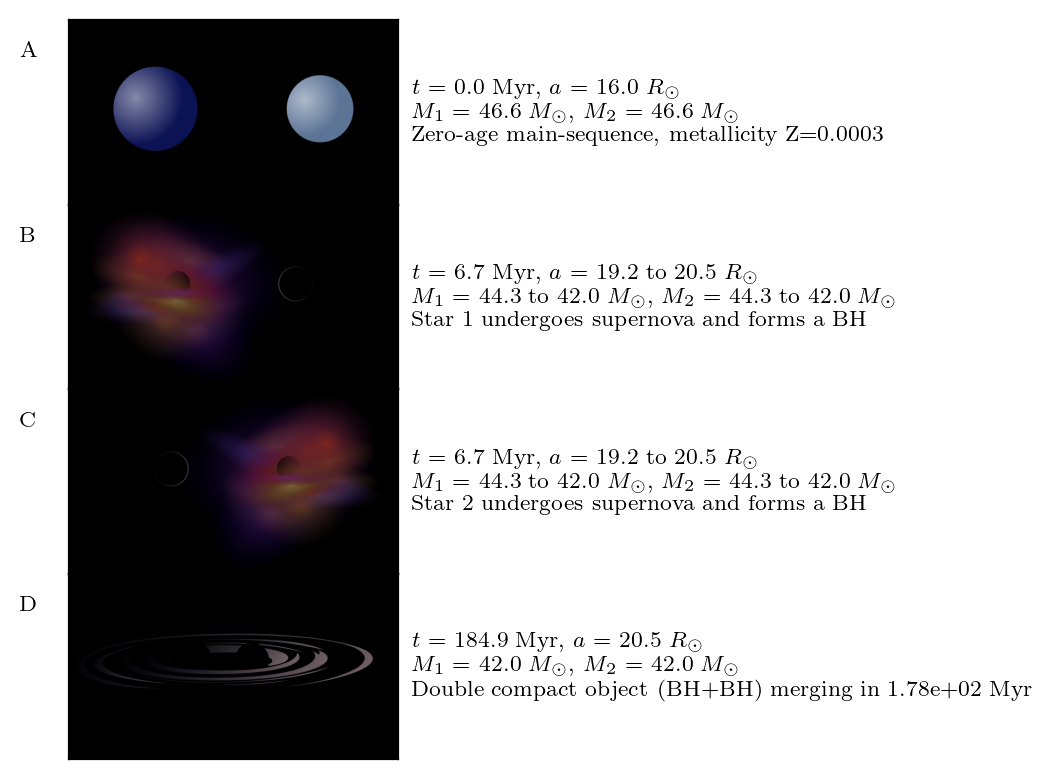

In [164]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [168]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)

df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

df_sanity_perfect

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
0,9976,0.000000,0.000064,16,16,413.221,413.221,385.359,385.359,13.93060,1.393060e+01,13.93060,1.393060e+01,2998.90,2998.90,2.998890e+03,2998.90,2.998890e+03,2998.90,0.000000,0,46.6202,6.787670,4.645240e-03,4.645240e-03,46.6202,6.787670,4.645240e-03,4.645240e-03,0.074247,0.074247,6.994450e-05,6.994450e-05,-6.994430e-05,-6.994430e-05,4.951580e-21,4.951580e-21,6.994470e-05,6.994470e-05,6.994450e-05,6.994450e-05,-6.994430e-05,-6.994430e-05,4.951580e-21,4.951580e-21,6.994470e-05,6.994470e-05,0,0,0,0,0,0,0,0,28.7038,3.890410,28.7038,3.890410,0,0,0,0,0,0,0,0,2.947940e+05,2.947940e+05,8.943740,8.943740,-4.593990e-20,-4.593990e-20,2.566480e-14,2.566480e-14,0,0,1.616180e+10,inf,1.168490e+09,1.168490e+09,-0.000009,-0.000009,0,0,0,0,0,0,0,0,0,0,7.181470e-06,7.181470e-06,-7.181450e-06,-7.181450e-06,5.083980e-22,5.083980e-22,7.181490e-06,7.181490e-06,-4.716830e-21,-4.716830e-21,-0.000000e+00,-0.000000e+00,2.635110e-15,2.635110e-15,15.965535,0.765258,0.765258,0.765258
1,9976,0.000064,0.063587,16,16,413.144,413.144,385.320,385.304,13.91220,1.392000e+01,13.91220,1.392000e+01,2996.85,2997.22,2.995530e+03,2997.22,2.995530e+03,2997.22,0.000000,0,46.6110,6.787670,4.644320e-03,4.644320e-03,46.6110,6.787670,4.644320e-03,4.644320e-03,0.074276,0.074270,6.974070e-05,6.974070e-05,-6.957720e-05,-6.957720e-05,4.957440e-13,4.957440e-13,6.990450e-05,6.990450e-05,6.974070e-05,6.974070e-05,-6.957720e-05,-6.957720e-05,4.957440e-13,4.957440e-13,6.990450e-05,6.990450e-05,0,0,0,0,0,0,0,0,28.6960,3.889780,28.6960,3.889780,0,0,0,0,0,0,0,0,2.946750e+05,2.946750e+05,8.942840,8.942840,-4.589160e-12,-4.589160e-12,2.563030e-06,2.563030e-06,0,0,1.618510e+02,inf,1.169260e+01,1.169260e+01,-0.009222,-0.009222,0,0,0,0,0,0,0,0,0,0,7.166290e-06,7.166290e-06,-7.149490e-06,-7.149490e-06,5.094080e-14,5.094080e-14,7.183120e-06,7.183120e-06,-4.715650e-13,-4.715650e-13,-0.000000e+00,-0.000000e+00,2.633670e-07,2.633670e-07,15.970460,0.765687,0.765687,0.765687
2,9976,0.063651,0.063597,16,16,413.067,413.067,385.264,385.249,13.90150,1.390940e+01,13.90150,1.390940e+01,2995.15,2995.52,2.993820e+03,2995.52,2.993820e+03,2995.52,0.000000,0,46.6016,6.787670,4.643390e-03,4.643390e-03,46.6016,6.787670,4.643390e-03,4.643390e-03,0.074299,0.074293,6.586430e-05,6.586430e-05,-6.570820e-05,-6.570820e-05,4.819220e-13,4.819220e-13,6.602070e-05,6.602070e-05,6.586430e-05,6.586430e-05,-6.570820e-05,-6.570820e-05,4.819220e-13,4.819220e-13,6.602070e-05,6.602070e-05,0,0,0,0,0,0,0,0,28.5735,3.863340,28.5735,3.863340,0,0,0,0,0,0,0,0,2.962680e+05,2.962680e+05,8.954900,8.954900,-4.453130e-12,-4.453130e-12,2.486420e-06,2.486420e-06,0,0

In [166]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,M1_conv_env,M1_core,M2_conv_env,M2_core,R1_conv_env_extent,R1_core,R2_conv_env_extent,R2_core,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,46.6202,46.6202,6.787670,6.787670,0,28.7038,0,28.7038,0,3.890410,0,3.890410,15.965535,0,16,16,0.765258,0.765258,0.765258,1.393060e+01,1.393060e+01,385.359,0,0,4.951580e-21,4.951580e-21,4.951580e-21,4.951580e-21,0,0,0,0,5.083980e-22,5.083980e-22
102,6.44365,44.6728,44.6728,6.787670,6.787670,0,16.2579,0,16.2579,0,1.261570,0,1.261570,17.028762,0,16,16,0.861138,0.861138,0.861138,1.186240e+01,1.186240e+01,373.310,0,0,5.797000e-28,5.797000e-28,5.797000e-28,5.797000e-28,0,0,0,0,6.596670e-25,6.596670e-25
103,6.44365,44.6572,44.6572,2.327780,2.327780,0,44.6572,0,44.6572,0,2.327780,0,2.327780,19.041226,0,7,7,1.018395,1.018395,1.018395,1.179290e+00,1.179290e+00,394.546,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-9.257060e-05,-9.257060e-05
145,6.72292,44.2648,44.2648,2.315410,2.315410,0,36.4221,0,36.4221,0,0.000072,0,0.000072,19.218628,0,7,7,1.037230,1.037230,1.037230,1.135540e+00,1.135540e+00,391.166,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-1.137100e-14,-1.137100e-14
146,6.72292,42.0491,42.0491,0.000178,0.000178,0,42.0491,0,42.0491,0,0.000178,0,0.000178,20.493661,0,14,14,1.171847,1.171847,1.171847,2.264410e-08,2.264410e-08,373.989,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,-2.030820e-03,-2.030820e-03
